In [1]:
# Python essential libraries
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cycler
from scipy.optimize import curve_fit
from scipy.special import erf
import astropy.units as u
import astropy.constants as const

from lmfit.lineshapes import gaussian

# Defining my matplotlib canvas template
## For black, set #000000. For navy, set #002060
defaultcolor = '#002060'
plt.rcParams.update({'text.color': defaultcolor, 'axes.labelcolor': defaultcolor, 
                     'xtick.color': defaultcolor, 'ytick.color': defaultcolor,
                     'axes.prop_cycle': cycler(color=['b', 'r', 'limegreen', 'orange']),
                     'font.family':'serif', 'font.serif': 'Times New Roman', 'mathtext.rm': 'serif',
                     'font.size': 22, 'lines.linewidth': 3,
                     'figure.figsize': (9.6, 5.4), 'figure.dpi': 100})

### Sampling

#### Cas A G17

In [735]:
def gaussian(x, A, mu, sigma):
    return A / (np.sqrt(2 * np.pi) * sigma) * np.exp(-(x - mu)**2 / (2 * sigma**2))

In [736]:
# System parameters
A = 35 * u.ph / u.cm**2 / u.s   # Amplitude of peak TODO: Depend on age, distance, and mass - only for Cas A
mu = 1157 * u.keV               # Line emission energy
fwhm = 7.5 * u.keV              # Instrumental line broadening (2.35 keV) # 9.1 keV, required performance; 5.3 keV, projected performance
sigma = fwhm / 2.355            # Converting to sigma, i.e., rms instrumental line broadening

In [737]:
# Function to calculate Doppler shifts
'''
vs towards the observer is negative
vs away from the observer is positive
For non-relativistic vs speeds
'''
def doppler_shift(E, vs):
    Eprime = const.c / (const.c + vs) * E
    return Eprime - E

# Linearly extrapolated version of Doppler broadening
# TODO: Verify correctness
'''
vmax is the highest absolute velocity of an 
expanding shell in the SN's rest frame
'''
# broadening = E0 * v/c
def doppler_broadening(E, vmax):
    # 3.86 keV for 1000 km/s
    # 1.93 keV for 500 km/s
    broadening = 3.86 * u.keV * (vmax / (1000 * u.km/u.s))
    return broadening

In [738]:
1157 * u.keV * 1000 * u.km/u.s / const.c.to(u.km/u.s)

<Quantity 3.85933658 keV>

In [739]:
E = 1157.02 * u.keV
vs = 10000 * u.km/u.s
E + doppler_shift(E, vs)

<Quantity 1119.67176991 keV>

In [740]:
fluxes = np.array([0.88, 1.23, 1.72, 1.13, 0.78, 1.25, 1.06, 0.64, 1.44, 0.96, 0.73]) * A.unit
centroids_68keV = np.array([67.35, 67.15, 69.5, 66.6, 67.6, 67.8, 67.8, 66.8, 67.4, 67.6, 67.1]) * u.keV
mu_68keV = 67.87 * u.keV
sigmas = np.array([5, 5, 15, 10, 15, 12, 12, 10, 11, 7, 5]) / 2 * u.keV

velocities = (const.c * (mu_68keV - centroids_68keV) / centroids_68keV).to(u.km/u.s)
centroids = mu + doppler_shift(mu, velocities)

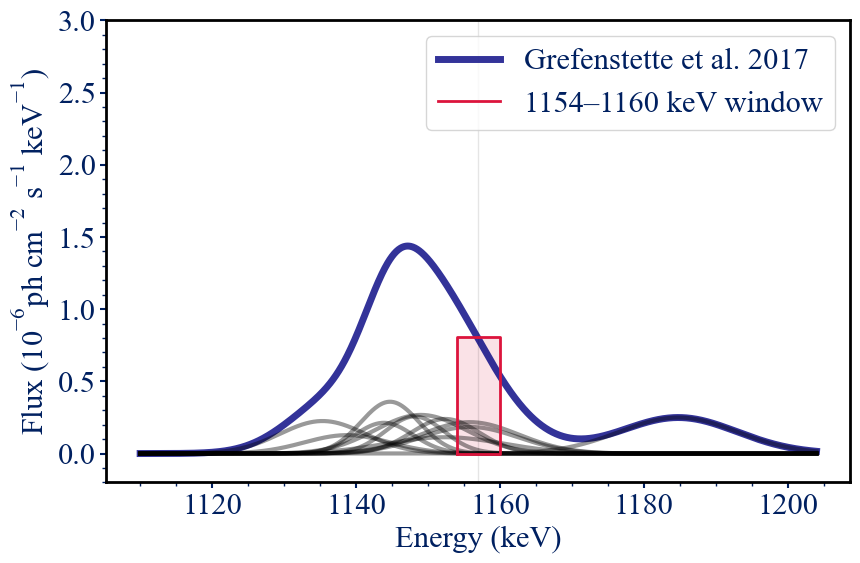

In [743]:
# Updated Doppler broadening values with upper constraints from G16

binwidth = 0.1 * u.keV
window = 47 * u.keV
nbins = int(2 * window / binwidth) + 1
mu_xdata = mu
xdata = np.linspace(mu_xdata - window, mu_xdata + window, nbins)

# Scaling observed clumps by flux observed from SPI (Siegert et al 2015)
signal_by_clump = u.Quantity([gaussian(xdata, flux, cen, np.sqrt(Dop_sig**2 + sigma**2)) for flux, cen, Dop_sig in zip(fluxes*A/np.sum(fluxes), centroids, sigmas)])
signal = np.sum(signal_by_clump, axis=0)

plt.figure(figsize=(9.6, 6))
plt.plot(xdata, signal, label='Grefenstette et al. 2017', c='navy', alpha=0.8, lw=5, ls='solid', zorder=2)
for s in signal_by_clump:
    plt.plot(xdata, s, c='k', alpha=0.4, lw=3)
plt.axvline(x=mu.value, alpha=0.1, lw=1, c='k')

# box outline over [Emin, Emax] from y=0 to y=ymax_box
Emin, Emax = 1154 * u.keV, 1160 * u.keV
mask = (xdata >= Emin) & (xdata <= Emax)
# Integrated band flux (ph cm^-2 s^-1)
F_window = np.sum((signal * binwidth)[mask])
# Height on a phi(E) plot so rectangle area equals F_window
y_top = (F_window / (Emax - Emin)).to_value(u.ph / u.cm**2 / u.s / u.keV)
plt.plot(
    [Emin.value, Emax.value, Emax.value, Emin.value, Emin.value],
    [0, 0, y_top, y_top, 0],
    color='crimson', lw=2,
    label=f'{Emin.value:g}–{Emax.value:g} keV window',
)
plt.fill_between([Emin.value, Emax.value], 0, y_top, color='crimson', alpha=0.12)
# plt.text(
#     0.02, 0.55,
#     f'Integrated flux in window = {F_window.to("ph/(cm2 s)"):0.3g}',
#     transform=plt.gca().transAxes, va='top',
# )

for spine in plt.gca().spines.values():
    spine.set_linewidth(2)
plt.gca().tick_params(width=1.5, length=4)
plt.gca().tick_params(which='minor', width=1, length=3)
plt.xlabel('Energy (keV)')
plt.ylabel('Flux ($\\mathregular{10^{-6}}$ph cm$\\mathregular{^{-2}}$ s$\\mathregular{^{-1}}$ keV$\\mathregular{^{-1}}$)')
plt.minorticks_on()
# plt.title('G17-like')
plt.ylim([-0.2,3])
plt.legend()
# plt.savefig('temp.png', bbox_inches='tight', transparent=True, dpi=300)
plt.show()

#### Sanity Checks

In [697]:
np.sum(signal*binwidth)

<Quantity 34.65959966 ph / (s cm2)>

In [698]:
np.sum(signal_by_clump * binwidth)

<Quantity 34.65959966 ph / (s cm2)>

In [700]:
# weights from your clump fluxes (only relative unless you also have an absolute total normalization)
w = (fluxes / np.sum(fluxes)).to_value(u.dimensionless_unscaled)

# Gaussian CDF fraction in [E1, E2] for each clump (area-normalized Gaussian)
z2 = ((Emax - centroids) / (np.sqrt(2) * sigmas)).to_value(u.dimensionless_unscaled)
z1 = ((Emin - centroids) / (np.sqrt(2) * sigmas)).to_value(u.dimensionless_unscaled)
frac_in_window_per_clump = 0.5 * (erf(z2) - erf(z1))  # unitless in [0,1]

# fraction of the *total* line flux that falls in 1154–1160 keV
frac_total_in_window = np.sum(w * frac_in_window_per_clump)

# if you know the absolute total line flux F_total (e.g. ph/cm2/s), get absolute flux in the window:
# F_window = frac_total_in_window * F_total
frac_total_in_window

0.1358662660287315

In [701]:
0.136 * 3.5e-5 * A.unit

<Quantity 4.76e-06 ph / (s cm2)>

#### Sampling

In [744]:
exposure_time = 3 * u.year
exposure_time_in_surveys = exposure_time / 2 * u.year
eff_area = 80/6 * 46134950 * u.cm**2 * u.s * exposure_time_in_surveys       # From cosipy 1154-1160 keV response. I have extrapolated this to +/- 40 keV (search key: "window")
num_photons = A * 1e-6 * eff_area
num_photons = num_photons.value.round().astype(int)
photons = np.random.choice(xdata, num_photons, p=signal/np.sum(signal))

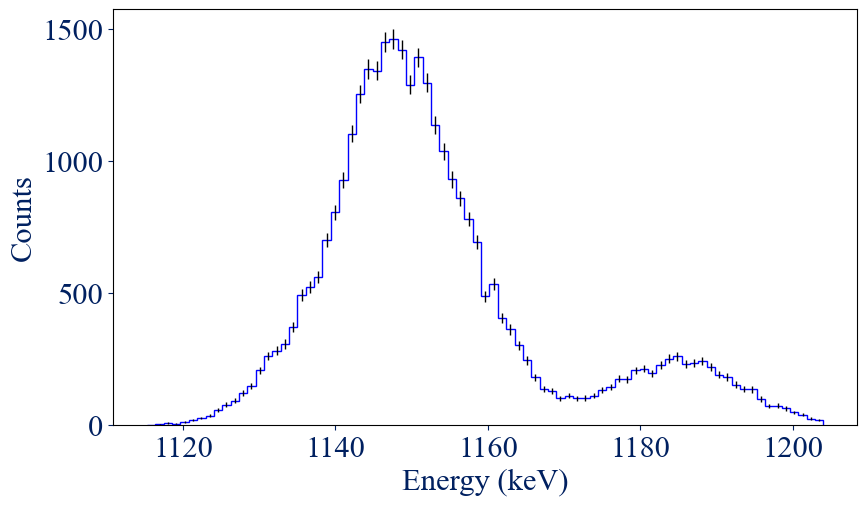

In [745]:
num_bins = 80
counts, bins, _ = plt.hist(photons, bins=num_bins + 1, histtype='step')
bg_counts_per_bin = num_photons * 0 / num_bins      # Bg counts: signal counts :: 0:1
counts_err = np.sqrt(counts + bg_counts_per_bin)
plt.errorbar(bins[:-1] + np.diff(bins)/2, counts, yerr=counts_err, fmt=' ', c='k', alpha=1, lw=1)
plt.xlabel('Energy (keV)')
plt.ylabel('Counts')
plt.show()

### Density and Velocity Fields

In [2]:
from SH_visualization_3 import *

setup_grid(n_theta=90, n_phi=180)

Grid initialized: 120x240
Grid initialized: 90x180


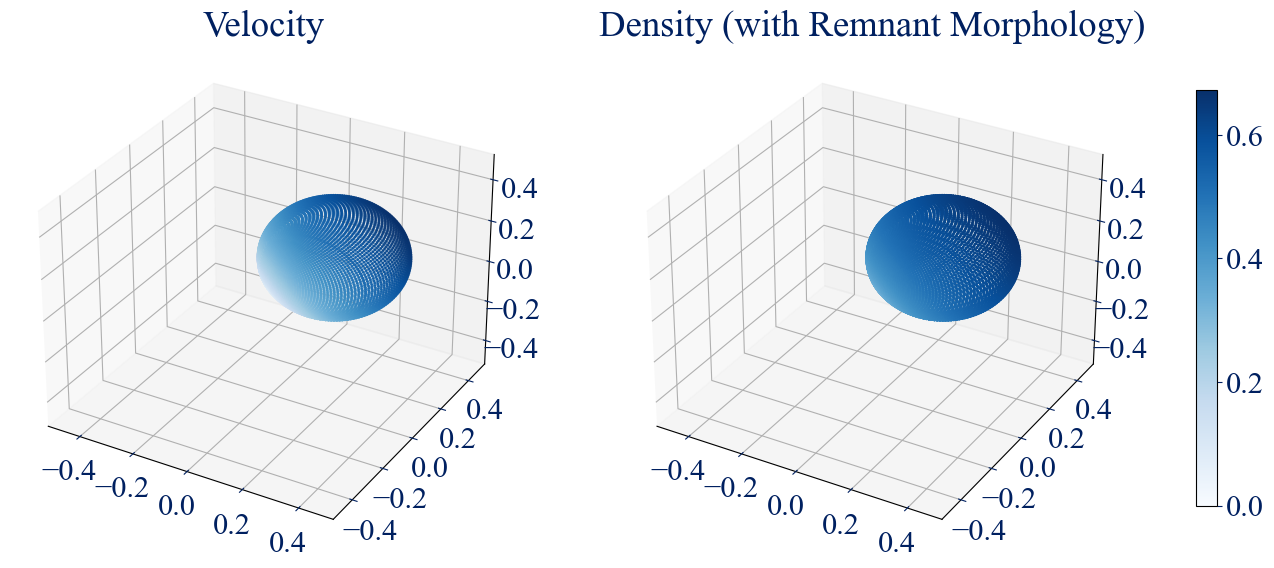

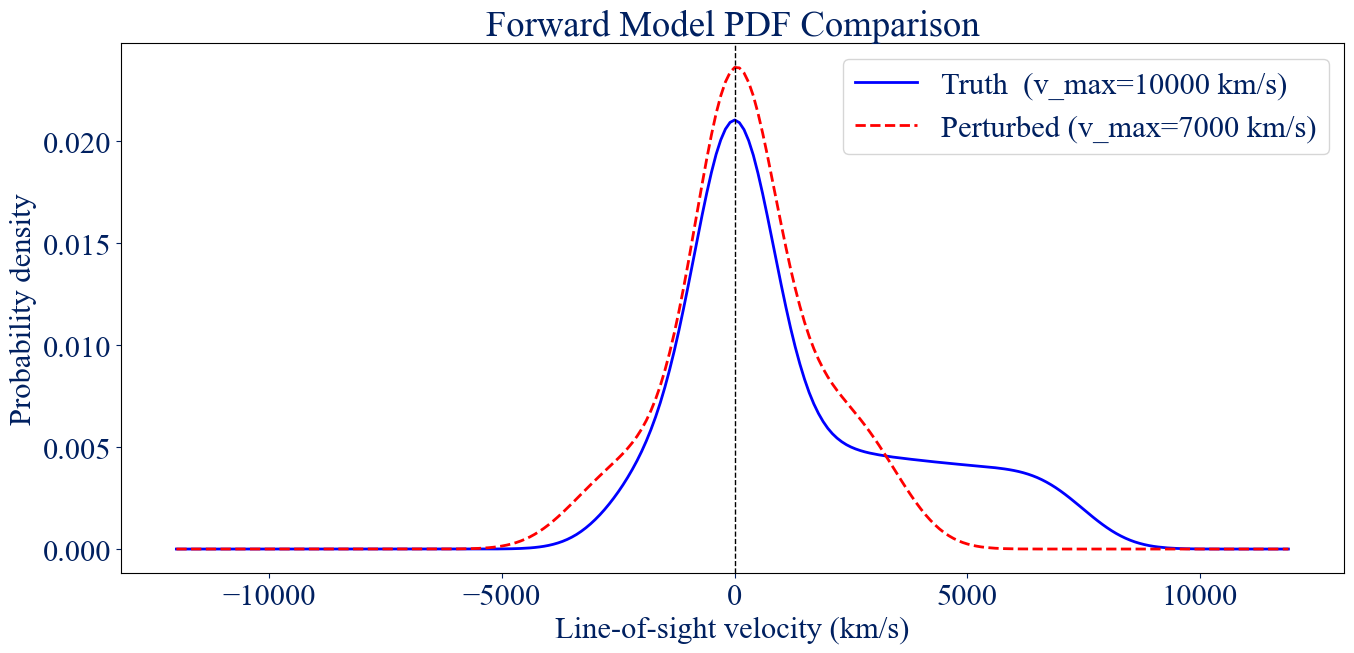

In [3]:
# ── Constants ──
nbins = 300
sum_type = 'unsigned'

# ── Model structure ──
l_den = [0, 1]
l_vel = [1]

# ── True params ──
params_true = np.array([
    1.0, 0.0,        0.0,        # density mode 0: l=0
    0.8, np.pi/3,    np.pi/4,    # density mode 1: l=1
    1.0, np.pi/3,    np.pi/4,    # velocity mode 0: l=1
    10000.0                        # v_max
])

density_modes, velocity_modes, v_max = params_to_modes(params_true, l_den, l_vel)

# ── Evaluate fields ──
density, velocity, weights = get_doppler_inputs(density_modes, velocity_modes, THETA, PHI, sum_type=sum_type)

# ── Plot fields ──
plot_two_fields(velocity, density, show_morphology=True)

# ── Forward model (truth) ──
pdf_true    = forward_model_pdf(params_true, l_den, l_vel, nbins=300)

# ── Perturbed model ──
params_perturbed          = params_true.copy()
params_perturbed[7]       = np.pi/2    # shift velocity theta_rot
params_perturbed[-1]      = 7000.0    # shift v_max

pdf_perturbed = forward_model_pdf(params_perturbed, l_den, l_vel, nbins=300)

# ── Evaluate PDFs on a common velocity axis ──
v_axis = np.arange(-12000, 12000, 100)

# ── Plot ──
fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(v_axis, pdf_true(v_axis),      lw=2, label='Truth  (v_max=10000 km/s)')
ax.plot(v_axis, pdf_perturbed(v_axis), lw=2, label='Perturbed (v_max=7000 km/s)', ls='--')
ax.axvline(0, color='k', lw=1, ls='--')
ax.set_xlabel("Line-of-sight velocity (km/s)")
ax.set_ylabel("Probability density")
ax.set_title(f"Forward Model PDF Comparison")
ax.legend()
plt.tight_layout()
plt.show()

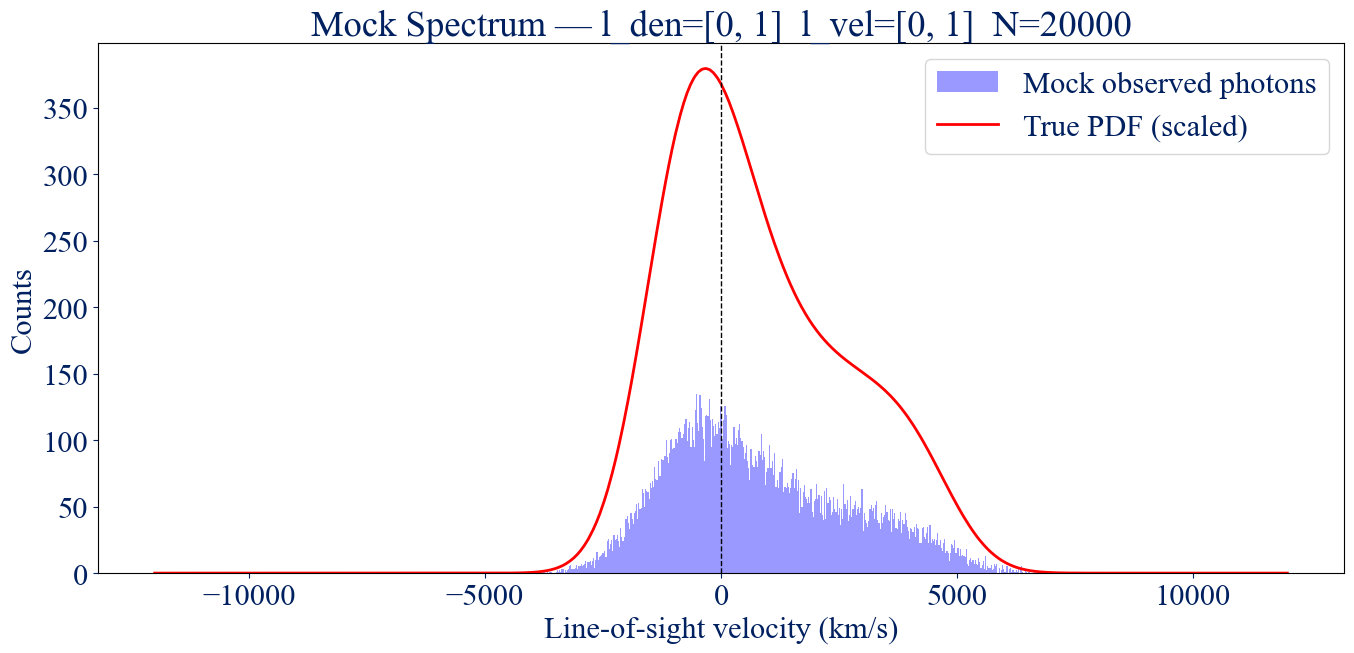

In [47]:
# ── Model structure ──
sum_type = 'unsigned'
l_den = [0, 1]
l_vel = [0, 1]

# ── True params: [A_den_0, t_den_0, p_den_0, A_vel_0, t_vel_0, p_vel_0, v_max] ──
params_true = np.array([
    1.0, 0.0, 0.0,   # density l=0
    0.8, np.pi/3, np.pi/4,   # density l=1
    1.0, 0.0, 0.0,   # velocity l=0
    1.3, np.pi/6, np.pi/2,   # velocity l=1
    5000.0           # v_max
])

# ── Forward model ──
# density_modes, velocity_modes, v_max = params_to_modes(params_true, l_den, l_vel)
# density, velocity, weights = get_doppler_inputs(density_modes, velocity_modes, THETA, PHI, sum_type=sum_type)
# plot_two_fields(velocity, density, show_morphology=True)
pdf_true = forward_model_pdf(params_true, l_den, l_vel, nbins=300)

# ── Generate mock observed photon velocities ──
v_axis      = np.linspace(-12000, 12000, 1001)
pdf_vals    = pdf_true(v_axis)
pdf_vals   /= pdf_vals.sum()   # ensure sums to 1 for np.random.choice

n_photons   = 20_000
v_observed  = np.random.choice(v_axis, size=n_photons, p=pdf_vals)

# ── Plot ──
fig, ax = plt.subplots(figsize=(14, 7))
ax.hist(v_observed, bins=v_axis, density=False, alpha=0.4, label='Mock observed photons')
ax.plot(v_axis, pdf_true(v_axis) * n_photons, lw=2, label='True PDF (scaled)')
ax.axvline(0, color='k', lw=1, ls='--')
ax.set_xlabel("Line-of-sight velocity (km/s)")
ax.set_ylabel("Counts")
ax.set_title(f"Mock Spectrum — l_den={l_den}  l_vel={l_vel}  N={n_photons}")
ax.legend()
plt.tight_layout()
plt.show()

In [7]:
A_MAX = 5.0

l_den = [0, 1]
l_vel = [0]

def log_likelihood(params):
    try:
        # if len(params) < get_ndim(l_den, l_vel):
        #     full_params = expand_params(params, l_den, l_vel)
        # else:
        #     full_params = params
        full_params = expand_params(params, l_den, l_vel)
        pdf = forward_model_pdf(full_params, l_den, l_vel, nbins=300)
        p_i = pdf(v_observed)             # evaluate PDF at each observed photon velocity
        p_i = np.clip(p_i, 1e-300, None)  # guard against log(0)
        return np.sum(np.log(p_i))
    except Exception:
        return -np.inf

def get_ndim(l_den, l_vel):
    n = 0
    first_mode_den    = True
    first_mode_vel    = True
    first_nonzero_any = True   # single global reference frame

    for l in l_den:
        if first_mode_den:
            first_mode_den = False
            if l == 0:
                pass                # no free params
            else:
                if first_nonzero_any:
                    n += 1          # theta_rot only (amplitude + phi_rot anchored)
                    first_nonzero_any = False
                else:
                    n += 2          # theta_rot + phi_rot (amplitude anchored)
        else:
            if l == 0:
                n += 1              # amplitude only
            else:
                if first_nonzero_any:
                    n += 2          # amplitude + theta_rot (phi_rot anchored)
                    first_nonzero_any = False
                else:
                    n += 3          # amplitude + theta_rot + phi_rot

    for l in l_vel:
        if first_mode_vel:
            first_mode_vel = False
            if l == 0:
                pass        # no free params
            else:
                if first_nonzero_any:
                    n += 1          # theta_rot only (amplitude + phi_rot anchored)
                    first_nonzero_any = False
                else:
                    n += 2          # theta_rot + phi_rot (amplitude anchored)
        else:
            if l == 0:
                n += 1
            else:
                if first_nonzero_any:
                    n += 2
                    first_nonzero_any = False
                else:
                    n += 3

    n += 1                          # v_max
    return n

def prior_transform(u):
    params = []
    i = 0
    first_mode_den    = True
    first_mode_vel    = True
    first_nonzero_any = True

    for l in l_den:
        if first_mode_den:
            first_mode_den = False
            if l == 0:
                pass        # no free params
            else:
                params.append(u[i] * np.pi)         # theta_rot
                i += 1
                if first_nonzero_any:
                    first_nonzero_any = False
                else:
                    params.append(u[i] * 2 * np.pi)         # phi_rot
                    i += 1
        else:
            params.append(u[i] * A_MAX)                 # amplitude free
            i += 1
            if l > 0:
                params.append(u[i] * np.pi)             # theta_rot
                i += 1
                if first_nonzero_any:
                    first_nonzero_any = False            # phi_rot anchored
                else:
                    params.append(u[i] * 2 * np.pi)     # phi_rot free
                    i += 1
    for l in l_vel:
        if first_mode_vel:
            first_mode_vel = False
            if l == 0:
                pass        # no free params
            else:
                params.append(u[i] * np.pi)         # theta_rot
                i += 1
                if first_nonzero_any:
                    first_nonzero_any = False
                else:
                    params.append(u[i] * 2 * np.pi)         # phi_rot
                    i += 1
        else:
            params.append(u[i] * A_MAX)
            i += 1
            if l > 0:
                params.append(u[i] * np.pi)
                i += 1
                if first_nonzero_any:
                    first_nonzero_any = False
                else:
                    params.append(u[i] * 2 * np.pi)
                    i += 1

    params.append(1000 + u[i] * 9000)
    return np.array(params)

def expand_params(params_reduced, l_den, l_vel):
    full = []
    i = 0
    first_mode_den    = True
    first_mode_vel    = True
    first_nonzero_any = True

    for l in l_den:
        if first_mode_den:
            first_mode_den = False
            full.append(1.0)                             # amplitude anchored
            if l == 0:
                full.append(0.0); full.append(0.0)
            else:
                full.append(params_reduced[i]); i += 1  # theta_rot
                if first_nonzero_any:
                    full.append(0.0)                         # phi_rot anchored
                    first_nonzero_any = False
                else:
                    full.append(params_reduced[i]); i += 1  # phi_rot
        else:
            full.append(params_reduced[i]); i += 1      # amplitude free
            if l == 0:
                full.append(0.0); full.append(0.0)
            else:
                full.append(params_reduced[i]); i += 1  # theta_rot
                if first_nonzero_any:
                    full.append(0.0)                     # phi_rot anchored
                    first_nonzero_any = False
                else:
                    full.append(params_reduced[i]); i += 1  # phi_rot free

    for l in l_vel:
        if first_mode_vel:
            first_mode_vel = False
            full.append(1.0)                             # amplitude anchored
            if l == 0:
                full.append(0.0); full.append(0.0)
            else:
                full.append(params_reduced[i]); i += 1   # theta_rot
                if first_nonzero_any:
                    full.append(0.0)                        # phi_rot anchored
                    first_nonzero_any = False
                else:
                    full.append(params_reduced[i]); i += 1  # phi_rot
        else:
            full.append(params_reduced[i]); i += 1
            if l == 0:
                full.append(0.0); full.append(0.0)
            else:
                full.append(params_reduced[i]); i += 1
                if first_nonzero_any:
                    full.append(0.0)
                    first_nonzero_any = False
                else:
                    full.append(params_reduced[i]); i += 1

    full.append(params_reduced[i])
    return np.array(full)

In [ ]:
from dataclasses import dataclass

@dataclass
class Param:
    value : float
    free  : bool = True
    lo    : float = 0.0
    hi    : float = 1.0
    
def reset_params_spec(l_den, l_vel, A_MAX=5.0, v_max_lo=1000, v_max_hi=10000):
    """
    Auto-generate params_spec from l_den, l_vel with correct free/frozen flags
    based on anchoring logic. User can then manually freeze/thaw individual
    entries afterwards.
    """
    specs = []
    first_mode_den    = True
    first_mode_vel    = True
    first_nonzero_any = True

    for l in l_den:
        if first_mode_den:
            first_mode_den = False
            specs.append(Param(value=1.0, free=False))              # amplitude anchored
            if l == 0:
                specs.append(Param(value=0.0, free=False))          # theta ignored
                specs.append(Param(value=0.0, free=False))          # phi ignored
            else:
                specs.append(Param(value=0.0, free=True,  lo=0, hi=np.pi))    # theta free
                specs.append(Param(value=0.0, free=False))          # phi anchored
                first_nonzero_any = False
        else:
            specs.append(Param(value=1.0, free=True, lo=0, hi=A_MAX))  # amplitude free
            if l == 0:
                specs.append(Param(value=0.0, free=False))
                specs.append(Param(value=0.0, free=False))
            else:
                specs.append(Param(value=0.0, free=True, lo=0, hi=np.pi))   # theta free
                if first_nonzero_any:
                    specs.append(Param(value=0.0, free=False))      # phi anchored
                    first_nonzero_any = False
                else:
                    specs.append(Param(value=0.0, free=True, lo=0, hi=2*np.pi))  # phi free

    for l in l_vel:
        if first_mode_vel:
            first_mode_vel = False
            specs.append(Param(value=1.0, free=False))              # amplitude anchored
            if l == 0:
                specs.append(Param(value=0.0, free=False))
                specs.append(Param(value=0.0, free=False))
            else:
                specs.append(Param(value=0.0, free=True, lo=0, hi=np.pi))
                if first_nonzero_any:
                    specs.append(Param(value=0.0, free=False))
                    first_nonzero_any = False
                else:
                    specs.append(Param(value=0.0, free=True, lo=0, hi=2*np.pi))
        else:
            specs.append(Param(value=1.0, free=True, lo=0, hi=A_MAX))
            if l == 0:
                specs.append(Param(value=0.0, free=False))
                specs.append(Param(value=0.0, free=False))
            else:
                specs.append(Param(value=0.0, free=True, lo=0, hi=np.pi))
                if first_nonzero_any:
                    specs.append(Param(value=0.0, free=False))
                    first_nonzero_any = False
                else:
                    specs.append(Param(value=0.0, free=True, lo=0, hi=2*np.pi))

    specs.append(Param(value=5000.0, free=True, lo=v_max_lo, hi=v_max_hi))  # v_max
    return specs

In [ ]:
def make_prior_transform(params_spec):
    free_specs = [p for p in params_spec if p.free]   # compute once, not every call
    def prior_transform(u):
        return np.array([p.lo + u[i]*(p.hi - p.lo) for i, p in enumerate(free_specs)])
    return prior_transform

def expand_params(params_reduced, params_spec):
    full = []
    j = 0
    for p in params_spec:
        if p.free:
            full.append(params_reduced[j]); j += 1
        else:
            full.append(p.value)
    return np.array(full)

def get_ndim(params_spec):
    return sum(p.free for p in params_spec)

def make_log_likelihood(params_spec, l_den, l_vel):
    def log_likelihood(params_reduced):
        try:
            full_params = expand_params(params_reduced, params_spec)
            pdf = forward_model_pdf(full_params, l_den, l_vel, nbins=300)
            p_i = np.clip(pdf(v_observed), 1e-300, None)
            return np.sum(np.log(p_i))
        except Exception:
            return -np.inf
    return log_likelihood

In [81]:
params_spec = [
    Param(value=1.0,      free=False),           # A_den_0 anchored
    Param(value=0.0,      free=False),           # t_den_0 ignored
    Param(value=0.0,      free=False),           # p_den_0 ignored
    Param(value=2,      free=True,  lo=0, hi=A_MAX),  # A_den_1
    Param(value=np.pi/3,  free=False,  lo=0, hi=np.pi),  # t_den_1
    Param(value=np.pi/4,  free=False),           # p_den_1 anchored
    Param(value=2,      free=True,  lo=0, hi=A_MAX),  # A_den_2
    Param(value=np.pi/3,  free=False,  lo=0, hi=np.pi),  # t_den_2
    Param(value=np.pi/4,  free=False),           # p_den_2 anchored
    Param(value=1.0,      free=False, lo=0, hi=A_MAX),  # A_vel_0 anchored
    Param(value=0.0,      free=False, lo=0, hi=np.pi),  # t_vel_0 ignored
    Param(value=0.0,      free=False),           # p_vel_0 ignored
    Param(value=2,      free=True, lo=0, hi=A_MAX),  # A_vel_1
    Param(value=np.pi/6,  free=False, lo=0, hi=np.pi),  # t_vel_1
    Param(value=np.pi/2,  free=False, lo=np.pi/4, hi=np.pi/4 + np.pi),           # p_vel_1
    Param(value=5000.0,   free=True, lo=1000, hi=10000),  # v_max
]

In [91]:
l_den = [0, 1, 2]
l_vel = [0, 1]

# ndim = get_ndim(l_den, l_vel)
prior_transform = make_prior_transform(params_spec)
log_likelihood = make_log_likelihood(params_spec, l_den, l_vel)
ndim = get_ndim(params_spec)
ndim

4

In [92]:
u_test = np.random.uniform(0, 1, ndim)
params_test = prior_transform(u_test)
print(params_test)

[   4.7291475     2.87190419    3.2376956  2567.54860949]


In [93]:
# Do this 10 times — if any return -inf, you have a problem
for _ in range(10):
    u = np.random.uniform(0, 1, ndim)
    p = prior_transform(u)
    ll = log_likelihood(p)
    print(p, "→", ll)

[8.66627649e-01 4.69434630e+00 1.14978236e+00 4.53663117e+03] → -90827.79023520135
[2.87374502e+00 2.63275330e+00 3.83607074e+00 7.88583301e+03] → -92997.63157659673
[3.33384582e+00 3.04246352e-01 6.22382944e-01 8.49150498e+03] → -97793.52179110219
[3.55663098e+00 3.37253663e+00 1.60198605e+00 6.06514979e+03] → -91163.75353144648
[4.53930954e+00 8.86840858e-01 4.14166126e+00 9.64622891e+03] → -95025.5841235462
[1.85926870e+00 4.86412393e+00 2.87141594e+00 8.35435107e+03] → -92900.42465883032
[1.50413803e+00 7.46128130e-01 3.87722155e+00 1.89591542e+03] → -292855.30315583886
[1.38928407e+00 2.31800124e+00 3.79918094e+00 9.38389185e+03] → -93757.41468352362
[4.50922225e-01 4.70808602e-01 2.46565846e+00 6.01093207e+03] → -91032.56038134123
[3.06920234e+00 1.17822503e+00 1.96374910e+00 4.65162164e+03] → -91107.54093796834


In [89]:
import dynesty

sampler = dynesty.NestedSampler(
    log_likelihood,
    prior_transform,
    ndim,
    nlive=200         # live points — more = more accurate but slower
)
sampler.run_nested(dlogz=0.5)   # stop when evidence changes < 0.5

results = sampler.results

100%|█████████▉| 2857/2858 [06:54<00:00,  6.89it/s, +200 | bound: 62 | nc: 1 | ncall: 20303 | eff(%): 15.207 | loglstar: -90539.853 | logz: -90553.391 +/-  0.255 | dlogz:  0.002 >  0.500]


log Z = -90553.39 ± 0.40
Best-fit params: [9.38193203e-01 3.53420711e-01 1.28295442e+00 5.00706712e+03]


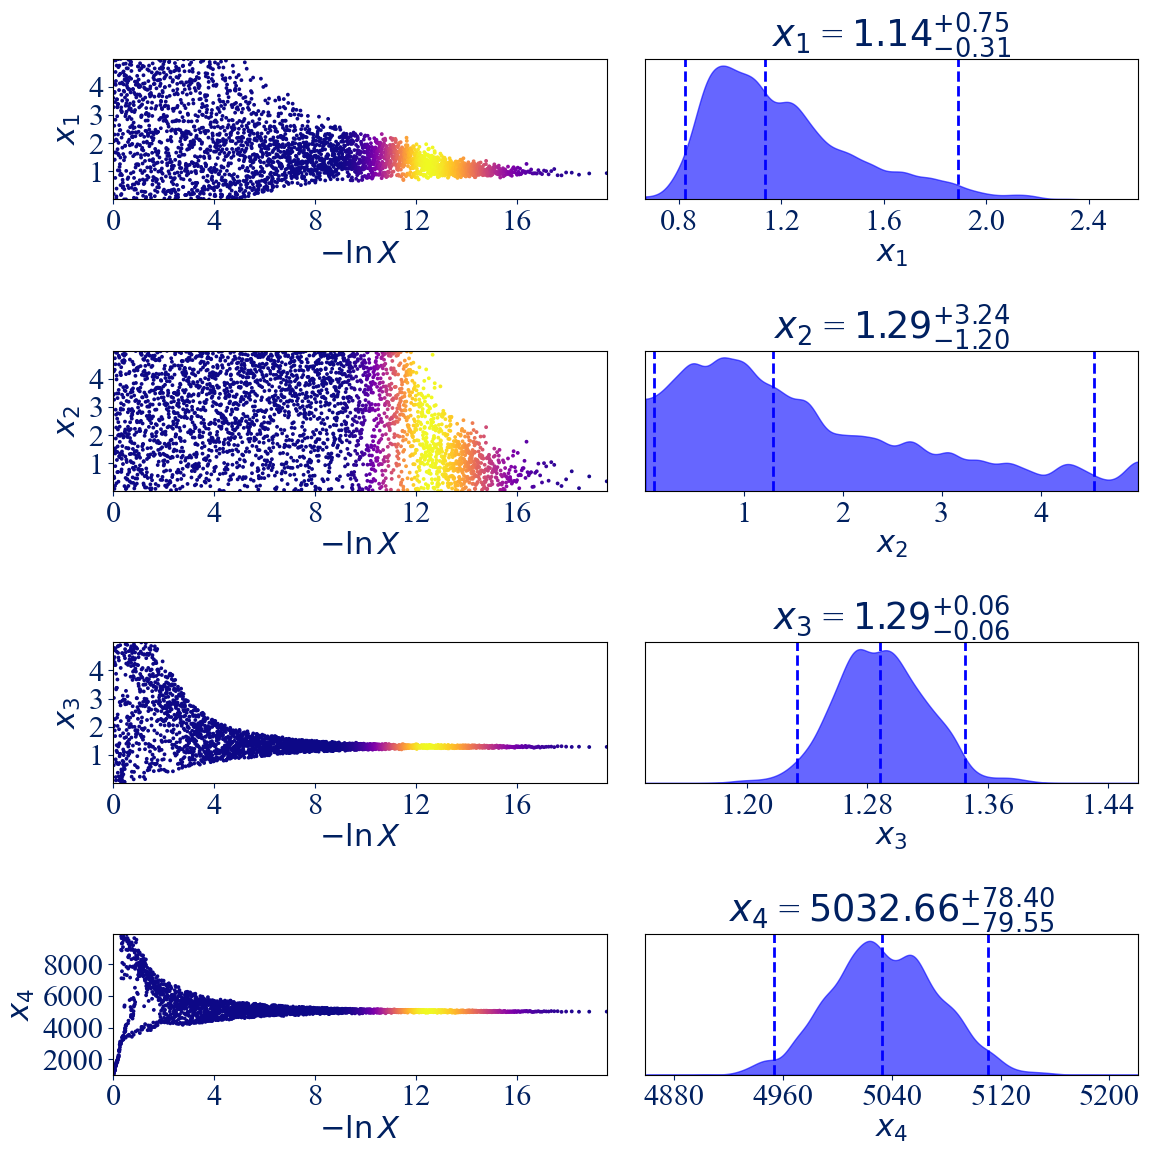

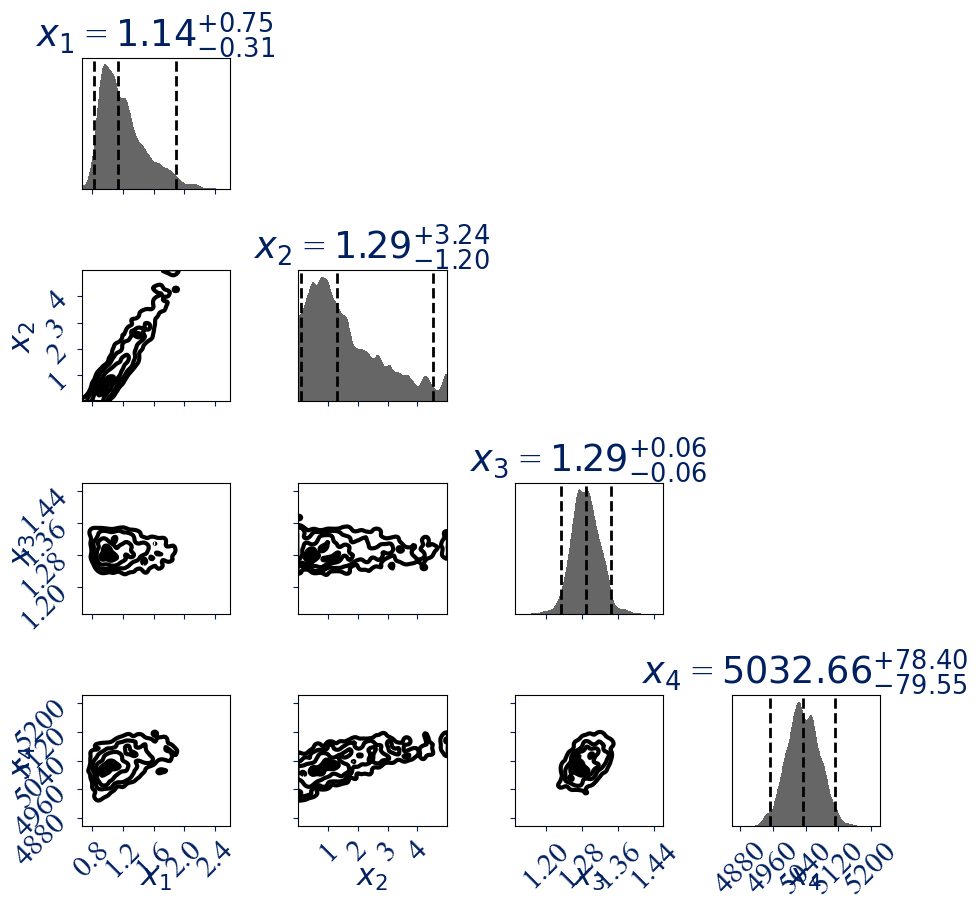

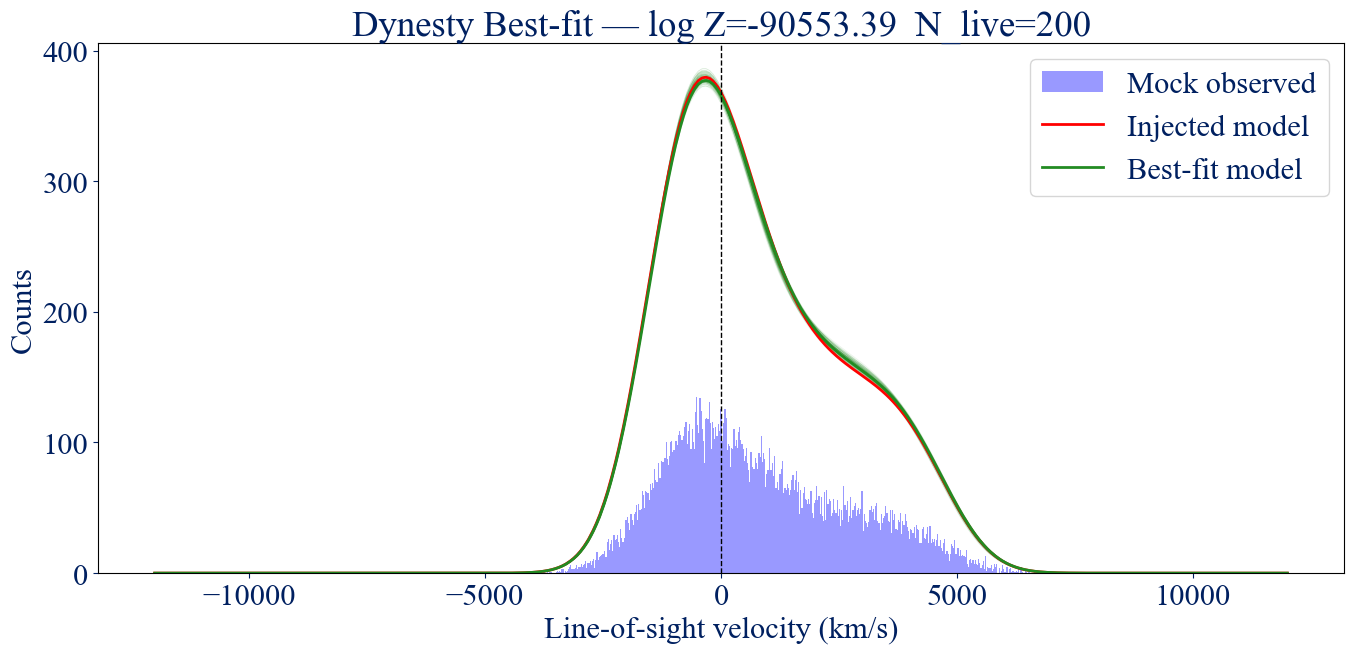

In [94]:
from dynesty import plotting as dyplot

# ── 1. Summary ──
print(f"log Z = {results.logz[-1]:.2f} ± {results.logzerr[-1]:.2f}")

# ── Equal-weighted posterior samples ──
samples = results.samples_equal()   # shape (N, ndim)
best    = results.samples[np.argmax(results.logl)]
print(f"Best-fit params: {best}")

# ── 2. Trace plot ──
fig, axes = dyplot.traceplot(results, show_titles=True)
plt.tight_layout()
plt.show()

# ── 3. Corner plot ──
fig, axes = dyplot.cornerplot(results, show_titles=True)
plt.tight_layout()
plt.show()

# ── 4. Best-fit spectrum vs mock data ──
pdf_best = forward_model_pdf(expand_params(best, params_spec), l_den, l_vel)
v_axis   = np.linspace(-12000, 12000, 1001)

fig, ax = plt.subplots(figsize=(14, 7))
ax.hist(v_observed, bins=v_axis, density=False, alpha=0.4, label='Mock observed')

# ── Posterior uncertainty band from random samples ──
n_draws = 100
for s in samples[np.random.choice(len(samples), n_draws, replace=False)]:
    pdf_s = forward_model_pdf(expand_params(s, params_spec), l_den, l_vel)
    ax.plot(v_axis, pdf_s(v_axis) * len(v_observed), lw=0.5, alpha=0.1, color='forestgreen')

ax.plot(v_axis, pdf_true(v_axis) * n_photons, lw=2, color='red', label='Injected model')
ax.plot(v_axis, pdf_best(v_axis) * len(v_observed), lw=2, color='forestgreen', label='Best-fit model')

ax.axvline(0, color='k', lw=1, ls='--')
ax.set_xlabel("Line-of-sight velocity (km/s)")
ax.set_ylabel("Counts")
ax.set_title(f"Dynesty Best-fit — log Z={results.logz[-1]:.2f}  N_live={sampler.nlive}")
ax.legend()
plt.tight_layout()
plt.show()

#### Plotting

In [99]:
# ── Define fields ──
theta_rot, phi_rot = np.pi/4, np.pi/8   # arbitrary axis
sum_type = 'unsigned'

density_modes = [
    # make_mode(l=0, m=0, theta_rot=theta_rot, phi_rot=phi_rot, amplitude=1.0),
    # make_mode(l=1, m=0, theta_rot=theta_rot, phi_rot=phi_rot, amplitude=0.7),
    make_mode(l=1, m=0, theta_rot=np.pi/3, phi_rot=np.pi/4, amplitude=0.7),
    # make_mode(l=1, m=0, theta_rot=np.pi*3/2, phi_rot=np.pi/6, amplitude=0.9),
    # make_mode(l=2, m=0, theta_rot=theta_rot, phi_rot=phi_rot, amplitude=1.0),
]

velocity_modes = [
    make_mode(l=0, m=0, theta_rot=theta_rot, phi_rot=phi_rot, amplitude=1.3),
    # make_mode(l=1, m=0, theta_rot=theta_rot, phi_rot=phi_rot, amplitude=1.0),
    # make_mode(l=1, m=0, theta_rot=np.pi, phi_rot=phi_rot, amplitude=1.0),
    make_mode(l=2, m=0, theta_rot=theta_rot, phi_rot=phi_rot, amplitude=-1.0),
]

density, velocity, weights = get_doppler_inputs(density_modes, velocity_modes, THETA, PHI, sum_type=sum_type)

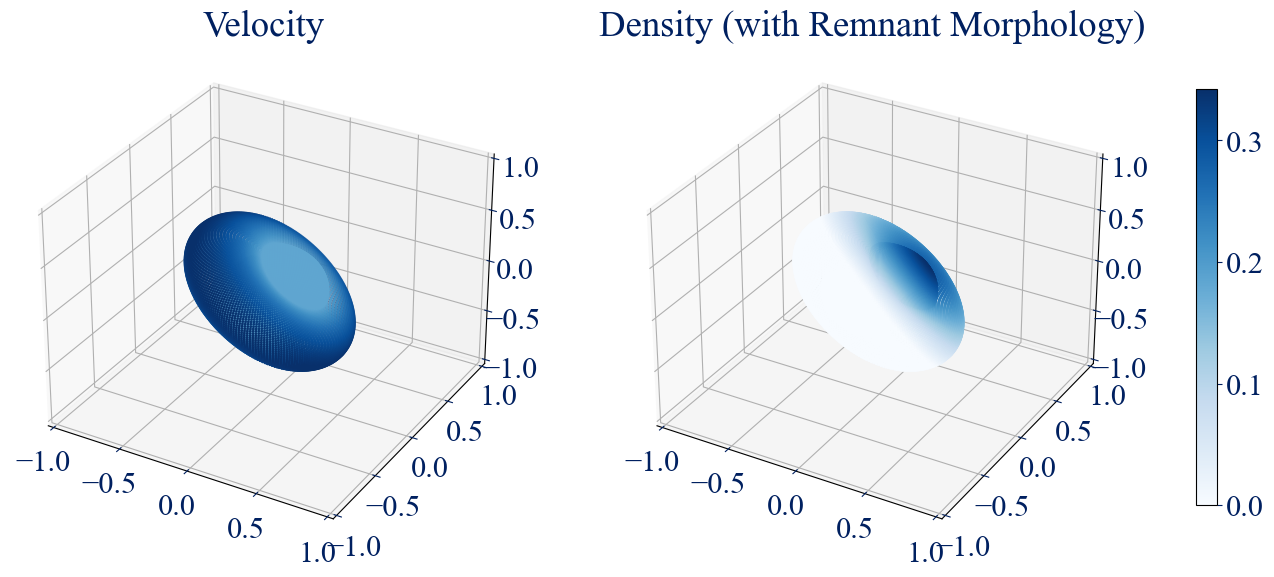

In [100]:
plot_two_fields(velocity, density, show_morphology=True, ex=1)
plt.show()

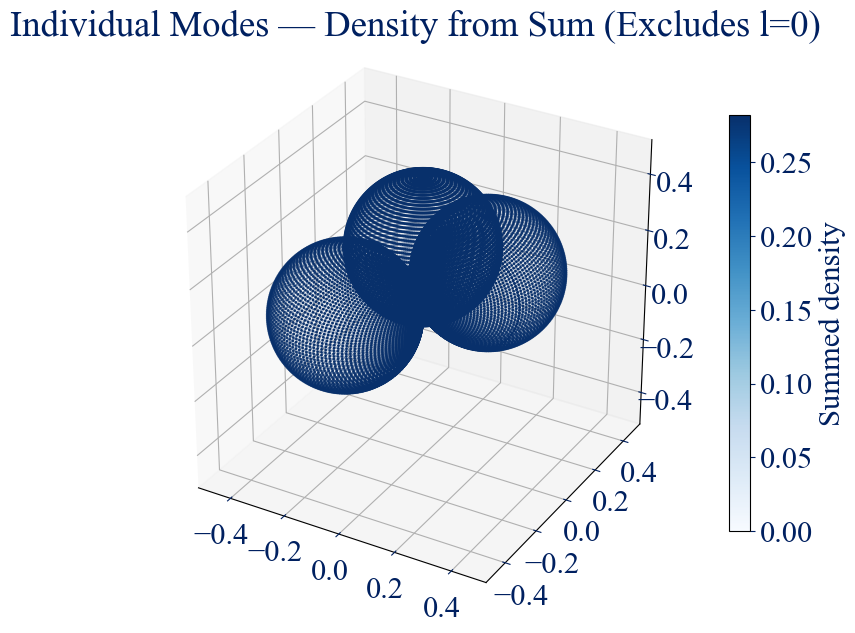

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(9, 9), subplot_kw={'projection': '3d'})

ex   = 0.5
norm = Normalize(vmin=0, vmax=Y_vel.max())

for mode in density_modes:
    if mode['l'] == 0:
        continue
    
    Y_mode              = eval_mode(mode, THETA, PHI, sum_type='unsigned')
    X_m, Y_m, Z_m       = spherical_to_cartesian(Y_mode, THETA, PHI)

    sc = ax.scatter(X_m, Y_m, Z_m, s=1, c=velocity['Y'], cmap='Blues', norm=norm)

ax.set_xlim(-ex, ex); ax.set_ylim(-ex, ex); ax.set_zlim(-ex, ex)
ax.set_box_aspect([1, 1, 1])
plt.title('Individual Modes — Density from Sum (Excludes l=0)')

fig.colorbar(sc, ax=ax, shrink=0.6, label='Summed density')
plt.show()

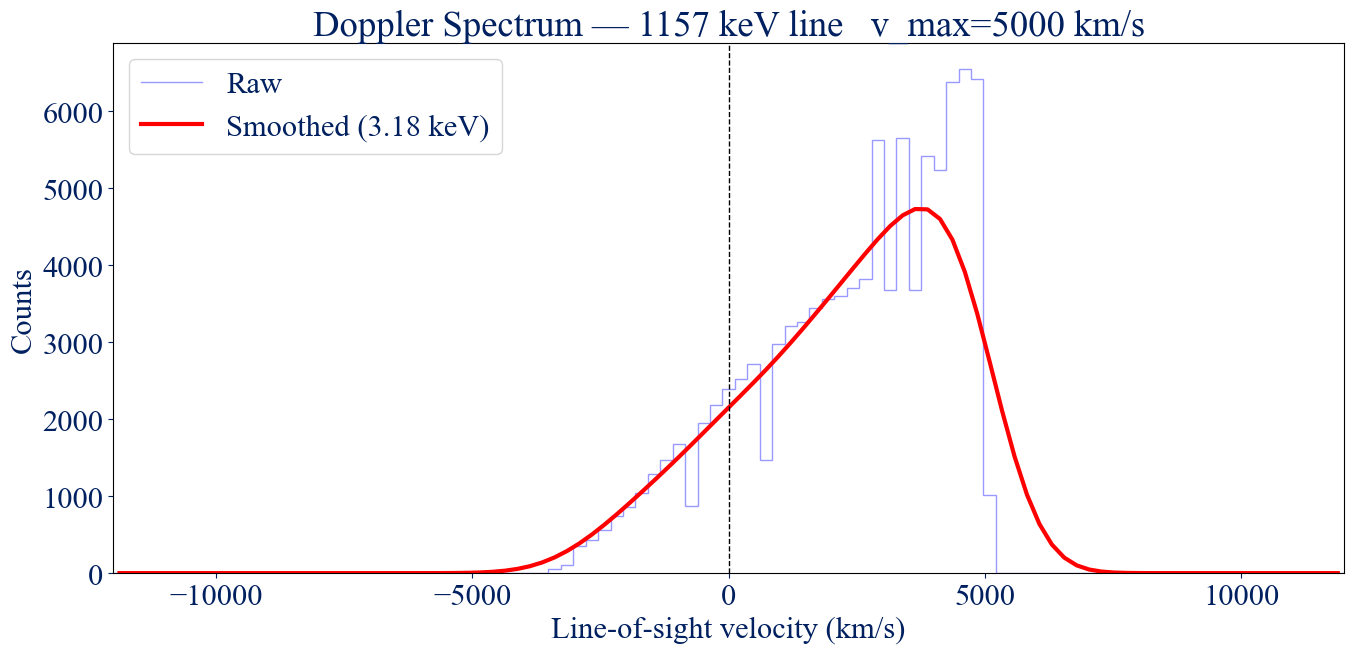

In [50]:
counts, edges, bin_centers, counts_smooth = get_doppler_spectrum(velocity['z'], velocity['Y'], weights, v_max=5000, nbins=100)
plot_doppler_spectrum(counts, edges, bin_centers, counts_smooth)

##### Jet

In [ ]:
# ── Define fields ──
theta_rot, phi_rot = np.pi/8, np.pi/4   # arbitrary axis
sum_type = 'unsigned'

density_modes = [make_mode(l=0, m=0, theta_rot=theta_rot, phi_rot=phi_rot, amplitude=1.0)]
# for l in range(1, 13, 2):
#     density_modes.append(make_mode(l=l, m=0, theta_rot=theta_rot, phi_rot=phi_rot, amplitude=1/l**1))

velocity_modes = []#[make_mode(l=0, m=0, theta_rot=theta_rot, phi_rot=phi_rot, amplitude=0.01)]
for l in range(1, 13, 2):
    velocity_modes.append(make_mode(l=l, m=0, theta_rot=theta_rot, phi_rot=phi_rot, amplitude=1/l**1))

density, velocity, weights = get_doppler_inputs(density_modes, velocity_modes, THETA, PHI, sum_type=sum_type)

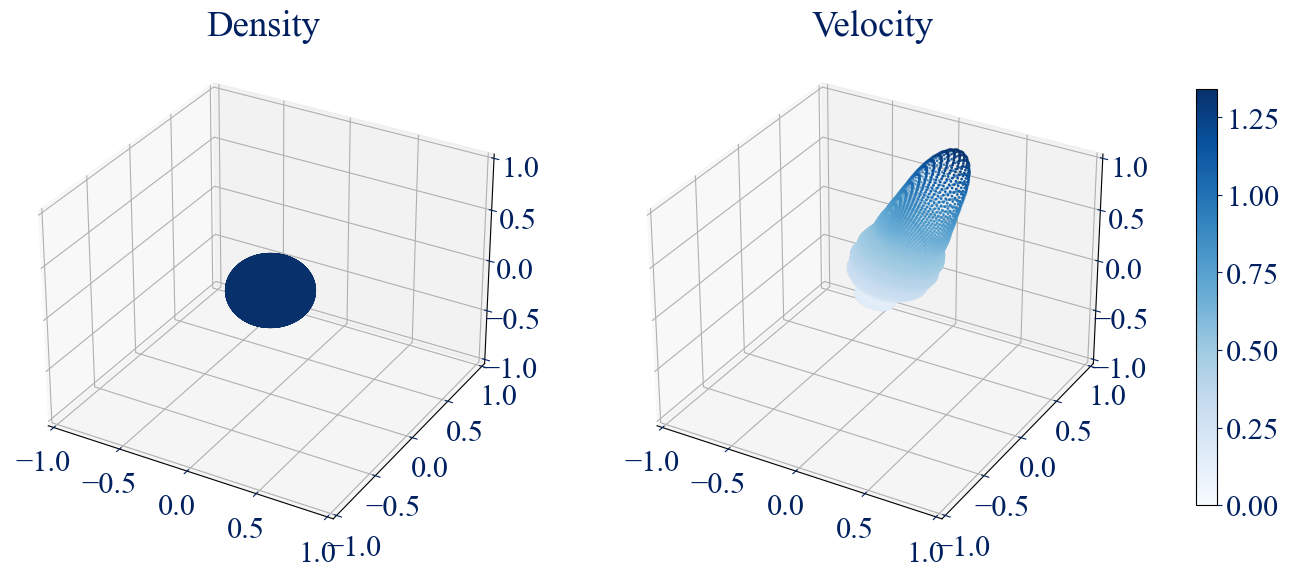

In [ ]:
plot_two_fields(velocity, density, show_morphology=True, ex=1)
plt.show()

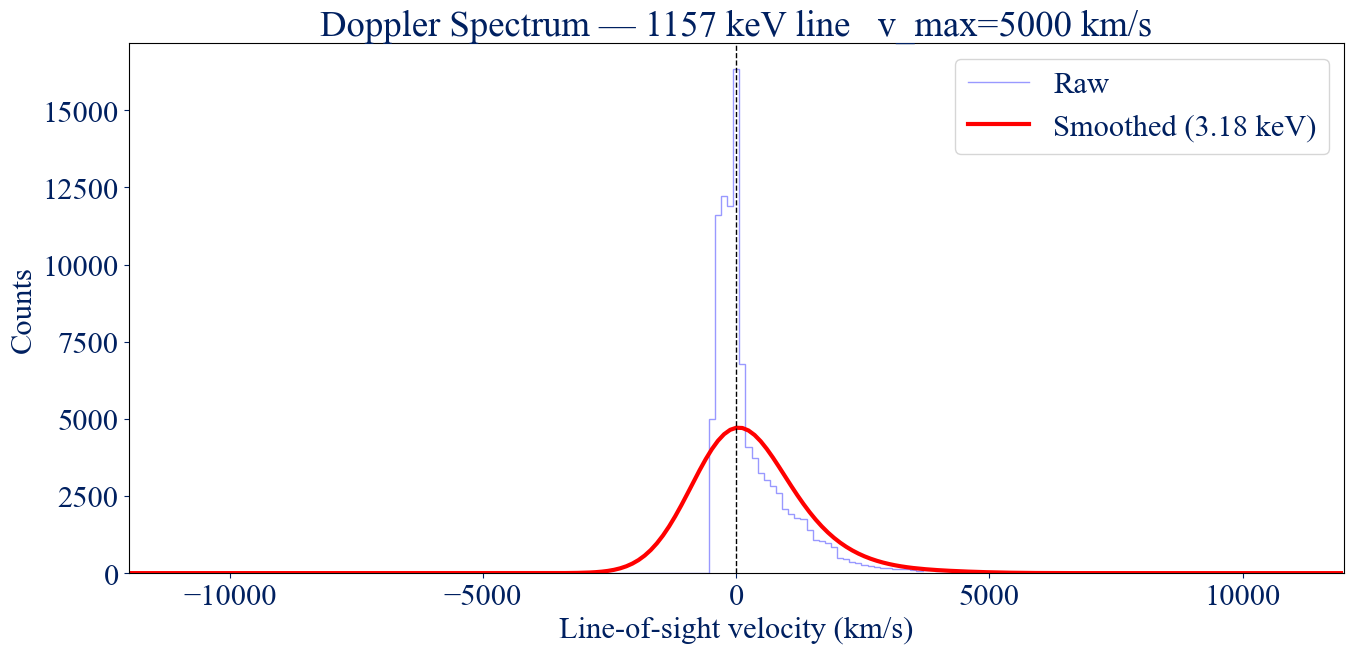

In [ ]:
counts, edges, bin_centers, counts_smooth = get_doppler_spectrum(velocity['z'], velocity['Y'], weights, nbins=200)
plot_doppler_spectrum(counts, edges, bin_centers, counts_smooth)

##### Angle rotation

In [95]:
# ── Define fields ──
theta_rot, phi_rot = np.pi/4, 0   # arbitrary axis
sum_type = 'unsigned'

densities_list = []
velocities_list = []
weights_list = []

for theta_rot in np.linspace(0, np.pi, 101):
    density_modes = [
        # make_mode(l=0, m=0, theta_rot=theta_rot, phi_rot=phi_rot, amplitude=1.0)
        make_mode(l=1, m=0, theta_rot=theta_rot, phi_rot=phi_rot, amplitude=1.0),
        make_mode(l=1, m=0, theta_rot=theta_rot, phi_rot=phi_rot + np.pi/2, amplitude=1.0)
        # make_mode(l=2, m=0, theta_rot=theta_rot, phi_rot=phi_rot, amplitude=0.6),      # disk-like outflow, effectively 0.5 * jet velocity
    ]

    velocity_modes = [
        # make_mode(l=2, m=0, theta_rot=theta_rot, phi_rot=phi_rot, amplitude=-1.0),       # asymmetric outflow
        # make_mode(l=1, m=0, theta_rot=theta_rot, phi_rot=phi_rot, amplitude=1.0),       # asymmetric outflow
        # make_mode(l=2, m=0, theta_rot=theta_rot, phi_rot=phi_rot, amplitude=1.0),       # jet-like outflow
        # make_mode(l=2, m=0, theta_rot=theta_rot, phi_rot=phi_rot, amplitude=-0.5),      # disk-like outflow, effectively 0.5 * jet velocity
        make_mode(l=0, m=0, theta_rot=theta_rot, phi_rot=phi_rot, amplitude=1),      # disk-like outflow, effectively 0.5 * jet velocity
    ]

    density, velocity, weights = get_doppler_inputs(density_modes, velocity_modes, THETA, PHI, sum_type=sum_type)

    densities_list.append(density)
    velocities_list.append(velocity)
    weights_list.append(weights)

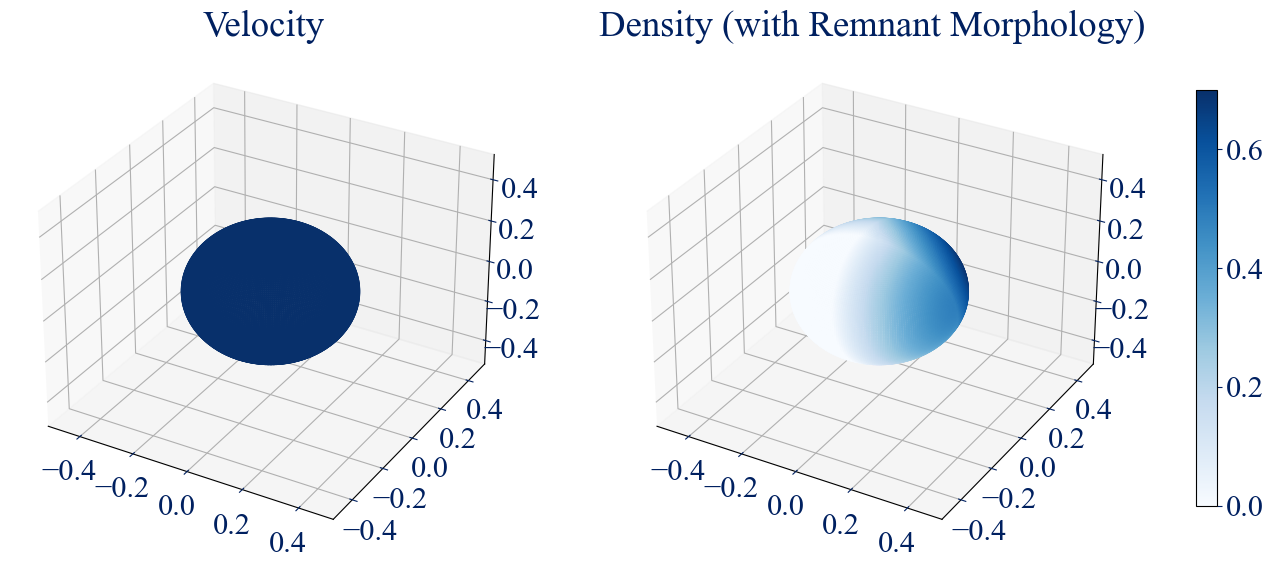

In [96]:
i = 45
plot_two_fields(velocities_list[i], densities_list[i], show_morphology=True)
plt.show()

In [97]:
v_max = 5000

counts_list = []
edges_list = []
bin_centers_list = []
counts_smooth_list = []

for i, theta_rot in enumerate(np.linspace(0, np.pi, 101)):
    counts, edges, bin_centers, counts_smooth = get_doppler_spectrum(velocities_list[i]['z'], velocities_list[i]['Y'], weights_list[i], v_max=v_max, nbins=200)
    counts_list.append(counts)
    edges_list.append(edges)
    bin_centers_list.append(bin_centers)
    counts_smooth_list.append(counts_smooth)

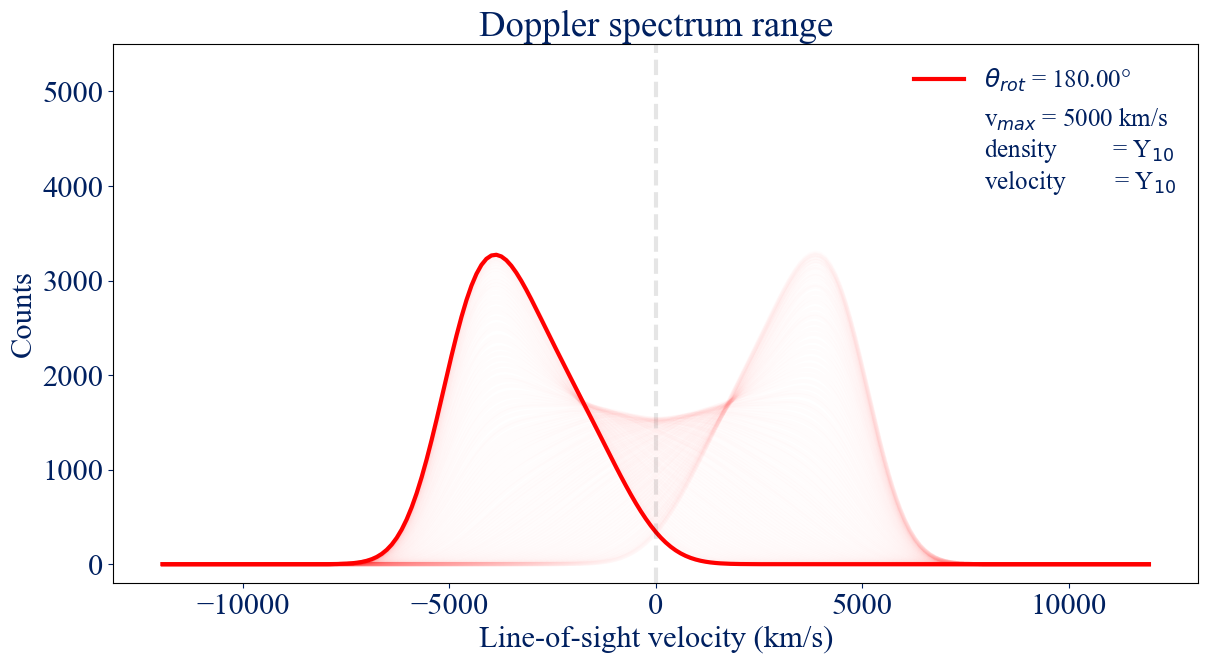

In [98]:
fig, ax = plt.subplots(figsize=(14, 7))

for i, theta_rot in enumerate(np.linspace(0, np.pi, 101)):
    ax.plot(bin_centers_list[i], counts_smooth_list[i], c='r', alpha=0.01)

j = 100
ax.plot(bin_centers_list[j], counts_smooth_list[j], c='r', label=f'$\\theta_{{rot}}$ = {np.rad2deg(np.linspace(0, np.pi, 101)[j]):.2f}°')

ax.axvline(0, c='k', ls='--', alpha=0.1)
ax.plot([], [], ' ', label=f'v$_{{max}}$ = {int(v_max)} km/s\ndensity\t\t= Y$_{{10}}$\nvelocity\t= Y$_{{10}}$')
ax.legend(fontsize=18, frameon=False)
ax.set_xlabel('Line-of-sight velocity (km/s)')
ax.set_ylabel('Counts')
ax.set_title(f'Doppler spectrum range')
ax.set_ylim([-200,5500])
plt.show()

In [214]:
# ── Define fields ──
theta_rot, phi_rot = np.pi/4, 0   # arbitrary axis
sum_type = 'unsigned'

densities_list = []
velocities_list = []
weights_list = []

for theta_rot in np.linspace(0, np.pi, 101):
    density_modes = [
        # make_mode(l=0, m=0, theta_rot=theta_rot, phi_rot=phi_rot, amplitude=1.0)
        make_mode(l=1, m=0, theta_rot=theta_rot, phi_rot=phi_rot, amplitude=1.0)
    ]

    velocity_modes = [
        make_mode(l=1, m=0, theta_rot=theta_rot, phi_rot=phi_rot, amplitude=1.0),       # asymmetric outflow
        # make_mode(l=2, m=0, theta_rot=theta_rot, phi_rot=phi_rot, amplitude=1.0),       # jet-like outflow
        # make_mode(l=2, m=0, theta_rot=theta_rot, phi_rot=phi_rot, amplitude=-1.0),      # disk-like outflow, effectively 0.5 * jet velocity
    ]

    density, velocity, weights = get_doppler_inputs(density_modes, velocity_modes, THETA, PHI, sum_type=sum_type)

    densities_list.append(density)
    velocities_list.append(velocity)
    weights_list.append(weights)

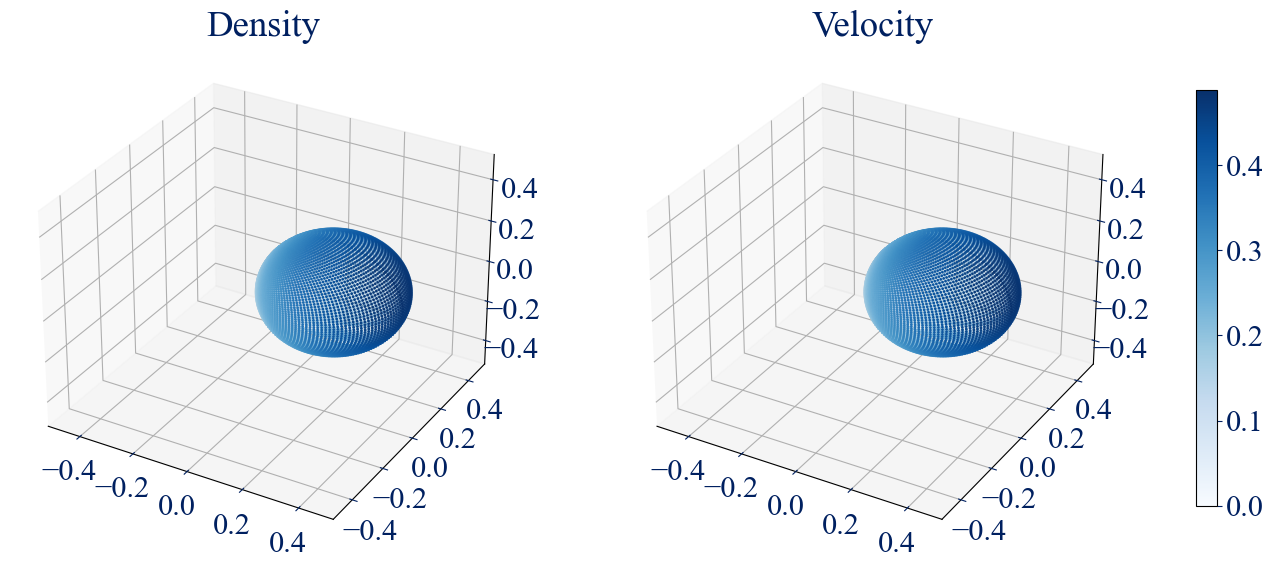

In [215]:
i = 39
plot_two_fields(densities_list[i], velocities_list[i])
plt.show()

In [216]:
v_max = 5000

counts_list = []
edges_list = []
bin_centers_list = []
counts_smooth_list = []

for i, theta_rot in enumerate(np.linspace(0, np.pi, 101)):
    counts, edges, bin_centers, counts_smooth = get_doppler_spectrum(velocities_list[i]['z'], velocities_list[i]['Y'], weights_list[i], v_max=v_max, nbins=200)
    counts_list.append(counts)
    edges_list.append(edges)
    bin_centers_list.append(bin_centers)
    counts_smooth_list.append(counts_smooth)

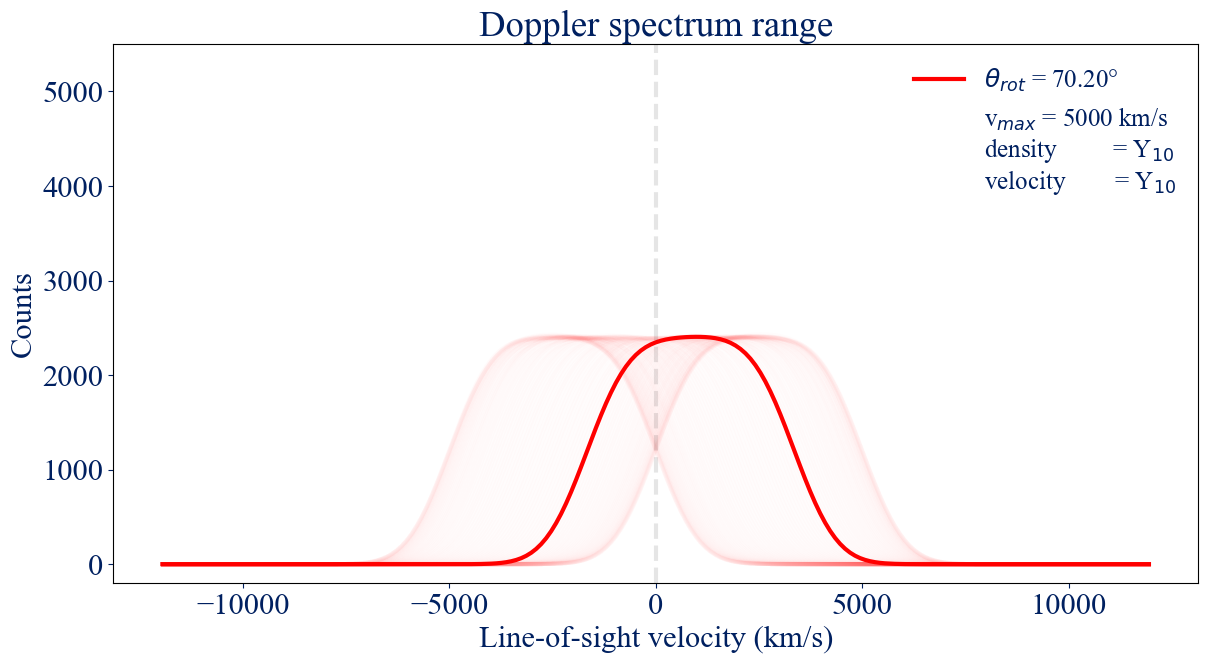

In [217]:
fig, ax = plt.subplots(figsize=(14, 7))

for i, theta_rot in enumerate(np.linspace(0, np.pi, 101)):
    ax.plot(bin_centers_list[i], counts_smooth_list[i], c='r', alpha=0.01)

j = 39
ax.plot(bin_centers_list[j], counts_smooth_list[j], c='r', label=f'$\\theta_{{rot}}$ = {np.rad2deg(np.linspace(0, np.pi, 101)[j]):.2f}°')

ax.axvline(0, c='k', ls='--', alpha=0.1)
ax.plot([], [], ' ', label=f'v$_{{max}}$ = {int(v_max)} km/s\ndensity\t\t= Y$_{{10}}$\nvelocity\t= Y$_{{10}}$')
ax.legend(fontsize=18, frameon=False)
ax.set_xlabel('Line-of-sight velocity (km/s)')
ax.set_ylabel('Counts')
ax.set_title(f'Doppler spectrum range')
ax.set_ylim([-200,5500])
plt.show()

In [207]:
# ── Define fields ──
theta_rot, phi_rot = np.pi/3, 0   # arbitrary axis
sum_type = 'unsigned'

densities_list = []
velocities_list = []
weights_list = []

for phi_rot in np.linspace(0, 2*np.pi, 101):
    density_modes = [
        make_mode(l=1, m=0, theta_rot=theta_rot, phi_rot=0, amplitude=1.0)
    ]

    velocity_modes = [
        make_mode(l=1, m=0, theta_rot=theta_rot, phi_rot=phi_rot, amplitude=1.0),       # asymmetric outflow
    ]

    density, velocity, weights = get_doppler_inputs(density_modes, velocity_modes, THETA, PHI, sum_type=sum_type)

    densities_list.append(density)
    velocities_list.append(velocity)
    weights_list.append(weights)

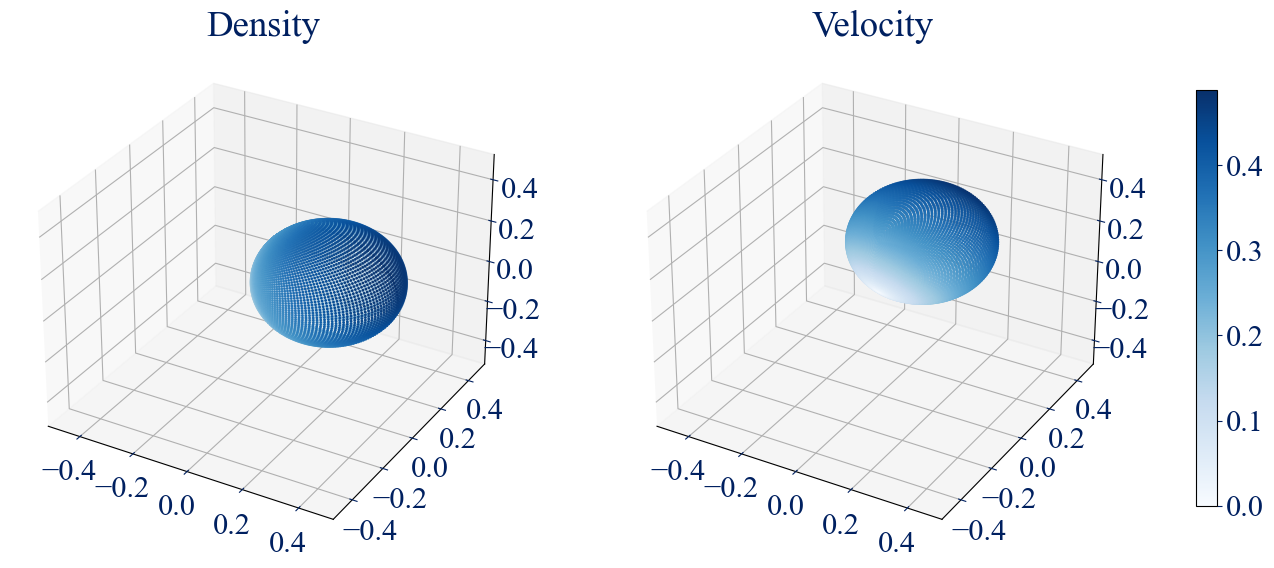

In [208]:
i = 22
plot_two_fields(densities_list[i], velocities_list[i])
plt.show()

In [209]:
v_max = 5000

counts_list = []
edges_list = []
bin_centers_list = []
counts_smooth_list = []

for i, phi_rot in enumerate(np.linspace(0, 2*np.pi, 101)):
    counts, edges, bin_centers, counts_smooth = get_doppler_spectrum(velocities_list[i]['z'], velocities_list[i]['Y'], weights_list[i], v_max=v_max, nbins=200)
    counts_list.append(counts)
    edges_list.append(edges)
    bin_centers_list.append(bin_centers)
    counts_smooth_list.append(counts_smooth)

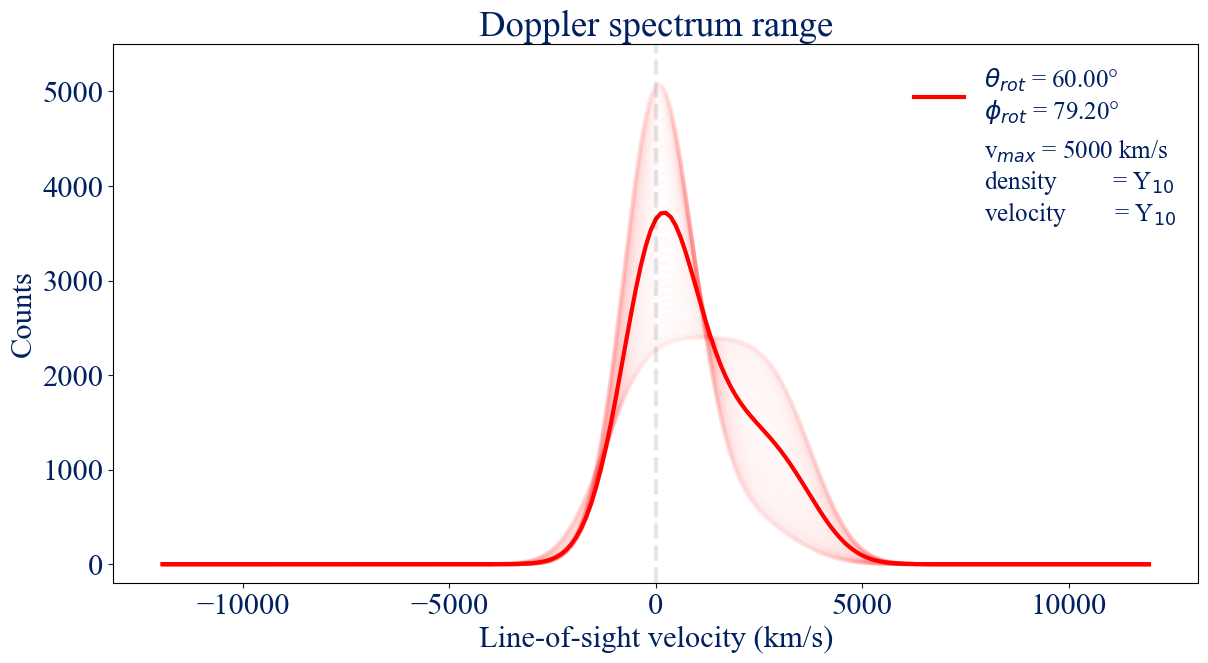

In [213]:
fig, ax = plt.subplots(figsize=(14, 7))

for i, phi_rot in enumerate(np.linspace(0, 2*np.pi, 101)):
    ax.plot(bin_centers_list[i], counts_smooth_list[i], c='r', alpha=0.01)

j = 22
ax.plot(bin_centers_list[j], counts_smooth_list[j], c='r', label=f'$\\theta_{{rot}}$ = {np.rad2deg(theta_rot):.2f}°\n$\\phi_{{rot}}$ = {np.rad2deg(np.linspace(0, 2*np.pi, 101)[j]):.2f}°')

ax.axvline(0, c='k', ls='--', alpha=0.1)
ax.plot([], [], ' ', label=f'v$_{{max}}$ = {int(v_max)} km/s\ndensity\t\t= Y$_{{10}}$\nvelocity\t= Y$_{{10}}$')
ax.legend(fontsize=18, frameon=False)
ax.set_xlabel('Line-of-sight velocity (km/s)')
ax.set_ylabel('Counts')
ax.set_title(f'Doppler spectrum range')
ax.set_ylim([-200,5500])
plt.show()

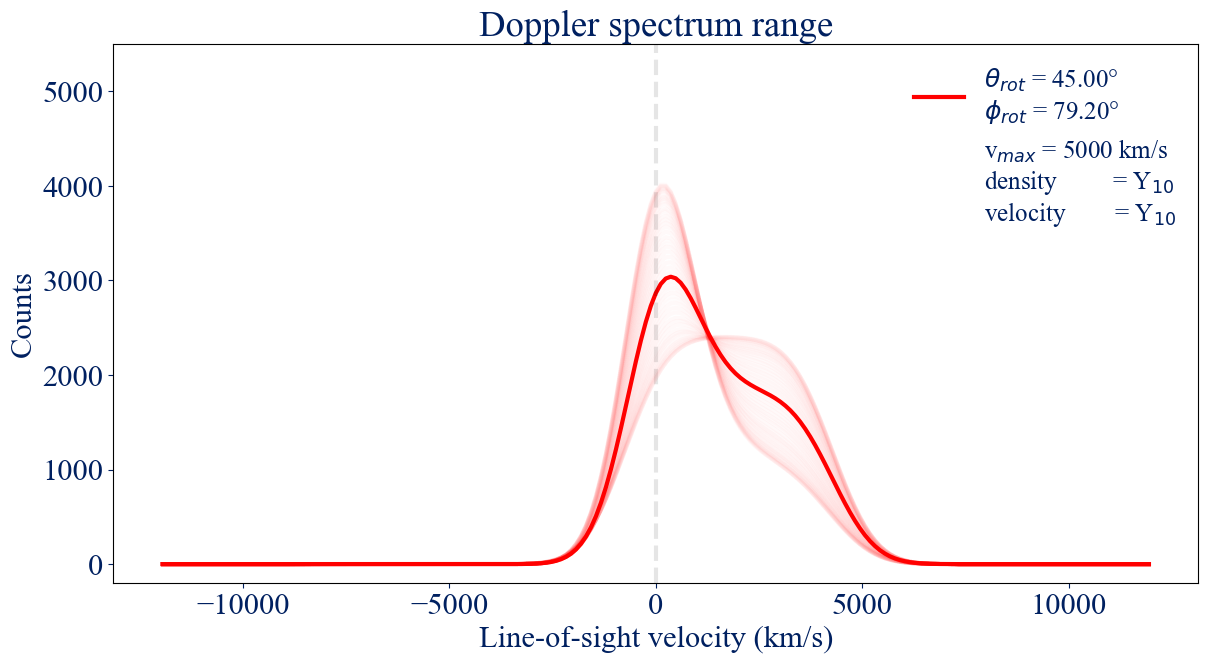

In [206]:
fig, ax = plt.subplots(figsize=(14, 7))

for i, phi_rot in enumerate(np.linspace(0, 2*np.pi, 101)):
    ax.plot(bin_centers_list[i], counts_smooth_list[i], c='r', alpha=0.01)

j = 22
ax.plot(bin_centers_list[j], counts_smooth_list[j], c='r', label=f'$\\theta_{{rot}}$ = {np.rad2deg(theta_rot):.2f}°\n$\\phi_{{rot}}$ = {np.rad2deg(np.linspace(0, 2*np.pi, 101)[j]):.2f}°')

ax.axvline(0, c='k', ls='--', alpha=0.1)
ax.plot([], [], ' ', label=f'v$_{{max}}$ = {int(v_max)} km/s\ndensity\t\t= Y$_{{10}}$\nvelocity\t= Y$_{{10}}$')
ax.legend(fontsize=18, frameon=False)
ax.set_xlabel('Line-of-sight velocity (km/s)')
ax.set_ylabel('Counts')
ax.set_title(f'Doppler spectrum range')
ax.set_ylim([-200,5500])
plt.show()

In [224]:
# ── Define fields ──
theta_rot, phi_rot = np.pi/4, 0   # arbitrary axis
sum_type = 'unsigned'

densities_list = []
velocities_list = []
weights_list = []

for theta_rot in np.linspace(0, np.pi, 101):
    density_modes = [
        make_mode(l=1, m=0, theta_rot=theta_rot, phi_rot=phi_rot, amplitude=1.0)
    ]

    velocity_modes = [
        make_mode(l=0, m=0, theta_rot=theta_rot, phi_rot=phi_rot, amplitude=2.0),       # spherical outflow
    ]

    density, velocity, weights = get_doppler_inputs(density_modes, velocity_modes, THETA, PHI, sum_type=sum_type)

    densities_list.append(density)
    velocities_list.append(velocity)
    weights_list.append(weights)

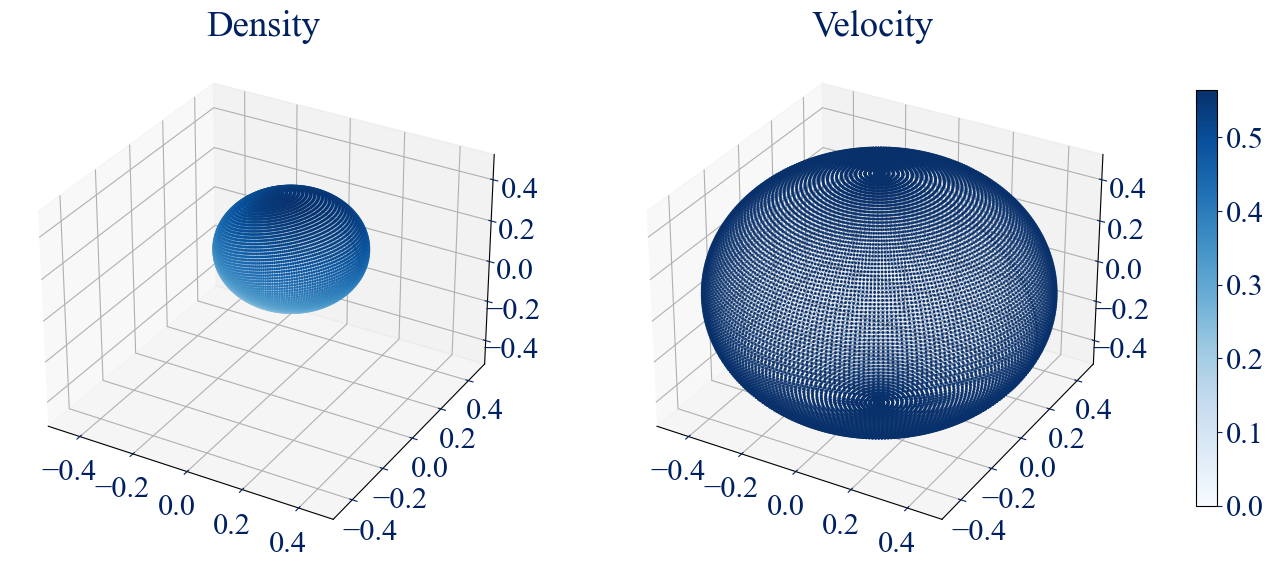

In [225]:
i = 10
plot_two_fields(densities_list[i], velocities_list[i])
plt.show()

In [226]:
v_max = 5000

counts_list = []
edges_list = []
bin_centers_list = []
counts_smooth_list = []

for i, theta_rot in enumerate(np.linspace(0, np.pi, 101)):
    counts, edges, bin_centers, counts_smooth = get_doppler_spectrum(velocities_list[i]['z'], velocities_list[i]['Y'], weights_list[i], v_max=v_max, nbins=200)
    counts_list.append(counts)
    edges_list.append(edges)
    bin_centers_list.append(bin_centers)
    counts_smooth_list.append(counts_smooth)

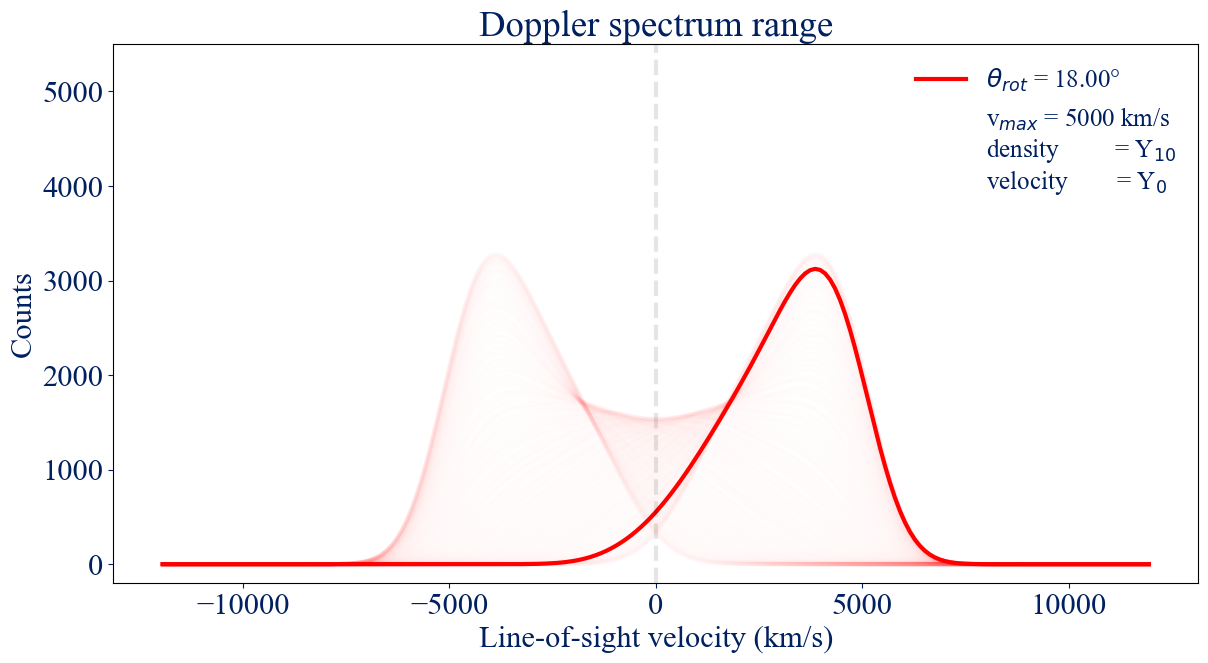

In [227]:
fig, ax = plt.subplots(figsize=(14, 7))

for i, theta_rot in enumerate(np.linspace(0, np.pi, 101)):
    ax.plot(bin_centers_list[i], counts_smooth_list[i], c='r', alpha=0.01)

j = 10
ax.plot(bin_centers_list[j], counts_smooth_list[j], c='r', label=f'$\\theta_{{rot}}$ = {np.rad2deg(np.linspace(0, np.pi, 101)[j]):.2f}°')

ax.axvline(0, c='k', ls='--', alpha=0.1)
ax.plot([], [], ' ', label=f'v$_{{max}}$ = {int(v_max)} km/s\ndensity\t\t= Y$_{{10}}$\nvelocity\t= Y$_{{0}}$')
ax.legend(fontsize=18, frameon=False)
ax.set_xlabel('Line-of-sight velocity (km/s)')
ax.set_ylabel('Counts')
ax.set_title(f'Doppler spectrum range')
ax.set_ylim([-200,5500])
plt.show()

##### Arrows and Poisson Fluctuations

In [ ]:
modes = [
    make_mode(l=0, m=0, theta_rot=np.pi/2,      phi_rot=np.pi/2,      amplitude=1.8),
    # make_mode(l=1, m=0, theta_rot=np.pi/6, phi_rot=0, amplitude=0.5),
    # make_mode(l=1, m=0, theta_rot=np.pi/3, phi_rot=np.pi/4, amplitude=1.),
    # make_mode(l=1, m=0, theta_rot=np.pi/2, phi_rot=np.pi, amplitude=1),
    # make_mode(l=1, m=0, theta_rot=np.pi/2, phi_rot=0, amplitude=1),
    # make_mode(l=1, m=0, theta_rot=0, phi_rot=np.pi/3, amplitude=0.8),
    # make_mode(l=2, m=0, theta_rot=np.pi/6, phi_rot=np.pi/3, amplitude=0.5),
    # make_mode(l=2, m=0, theta_rot=0, phi_rot=np.pi/3, amplitude=-1),
    # make_mode(l=2, m=0, theta_rot=-np.pi/2, phi_rot=np.pi/3, amplitude=-1),
]

Y_sum = sum_modes(modes, THETA, PHI, sum_type='signed')
Y_sum = np.random.poisson(Y_sum * 100) / 100

# Build Cartesian surface from the positive-definite sum
X_cart, Y_cart, Z_cart = spherical_to_cartesian(Y_sum, THETA, PHI)

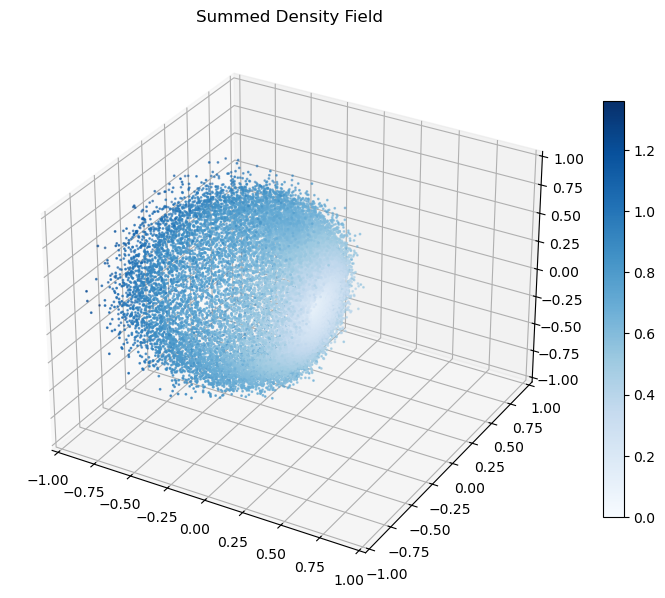

In [430]:
fig, ax = plt.subplots(1, 1, figsize=(9, 9), subplot_kw={'projection': '3d'})

ex = 1
sc = ax.scatter(X_cart, Y_cart, Z_cart, s=1, c=Y_sum, cmap='Blues', norm=Normalize(vmin=0))
ax.set_xlim(-ex, ex); ax.set_ylim(-ex, ex); ax.set_zlim(-ex, ex)

plt.title('Summed Density Field')
plt.colorbar(sc, shrink=0.6)#, label=fr'Y$_{}$')
plt.show()

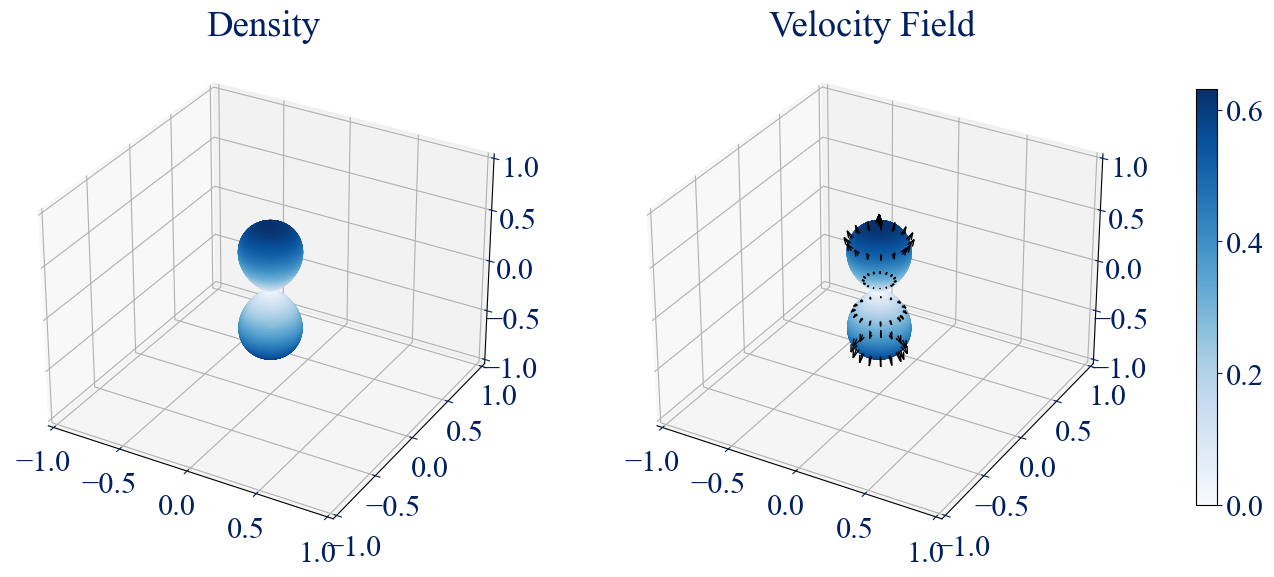

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(18, 9), subplot_kw={'projection': '3d'})

ex = 1
step = 31

sc = axs[0].scatter(rho_x, rho_y, rho_z, s=1, c=Y_den, cmap='Blues', norm=Normalize(vmin=0, vmax=Y_den.max()))
axs[0].set_xlim(-ex, ex); axs[0].set_ylim(-ex, ex); axs[0].set_zlim(-ex, ex)
axs[0].set_title('Density')

x_ = V_x[::step, ::step].ravel()
y_ = V_y[::step, ::step].ravel()
z_ = V_los[::step, ::step].ravel()

# Arrow directions = unit radial vector scaled by velocity magnitude
speed = Y_vel[::step, ::step].ravel()
ux = (V_x / Y_vel.max())[::step, ::step].ravel()   # normalized x-component
uy = (V_y / Y_vel.max())[::step, ::step].ravel()   # normalized y-component
uz = (V_los / Y_vel.max())[::step, ::step].ravel() # normalized z-component

axs[1].scatter(V_x, V_y, V_los, s=1, c=Y_vel, cmap='Blues', norm=Normalize(vmin=0, vmax=Y_vel.max()))
axs[1].quiver(x_, y_, z_,        # arrow origins
              ux, uy, uz,         # arrow directions
              length=0.1,         # base arrow length
              normalize=False,    # keep length proportional to speed
              color='k',
              linewidths=1,
              arrow_length_ratio=0.9,
              )

axs[1].set_xlim(-ex, ex); axs[1].set_ylim(-ex, ex); axs[1].set_zlim(-ex, ex)
axs[1].set_title('Velocity Field')

plt.colorbar(sc, ax=axs, shrink=0.6)
plt.show()

##### Physical Frame Rotation Code

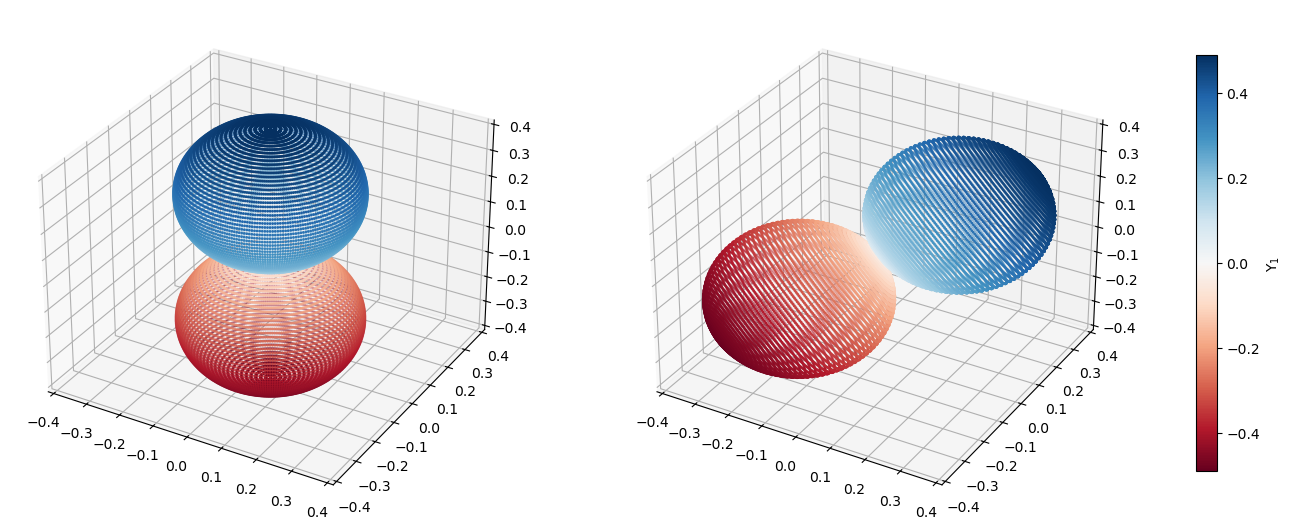

In [ ]:
# ── Y_1^0 (real part) as radial extent of velocities ──
Y_1 = sph_harm_y(1, 0, THETA, PHI).real   # signed, for colormap
X_cart, Y_cart, Z_cart = spherical_to_cartesian(np.abs(Y_1), THETA, PHI)

# Define rotation
theta_rot, phi_rot = np.pi/3, np.pi/4
R = get_rotation_matrix(theta_rot, phi_rot)

# Apply rotation
pts = np.stack([X_cart.ravel(), Y_cart.ravel(), Z_cart.ravel()])  # (3, N)
X_rot, Y_rot, Z_rot = (R.as_matrix() @ pts).reshape(3, *X_cart.shape)

fig, axs = plt.subplots(1, 2, figsize=(18, 9), subplot_kw={'projection': '3d'})

sc = axs[0].scatter(X_cart, Y_cart, Z_cart, s=1, c=Y_1, cmap='RdBu')
axs[0].set_xlim(-0.4, 0.4); axs[0].set_ylim(-0.4, 0.4); axs[0].set_zlim(-0.4, 0.4)

sc = axs[1].scatter(X_rot, Y_rot, Z_rot, s=1, c=Y_1, cmap='RdBu')
axs[1].set_xlim(-0.4, 0.4); axs[1].set_ylim(-0.4, 0.4); axs[1].set_zlim(-0.4, 0.4)

plt.colorbar(sc, ax=axs, shrink=0.6, label='Y$_1$')
plt.show()

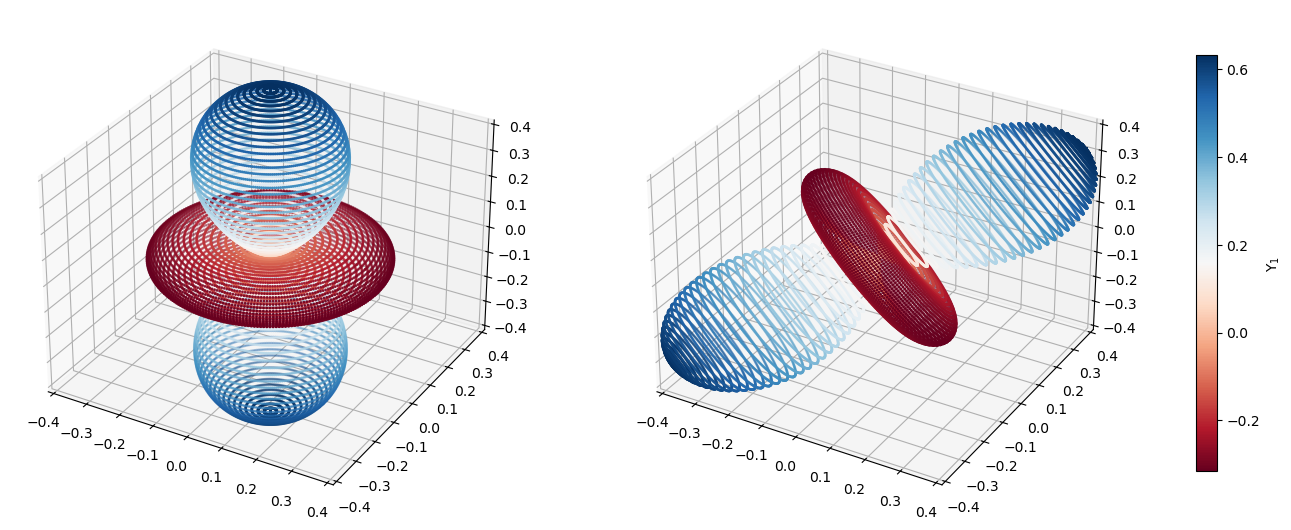

In [6]:
# ── Y_2^0 (real part) as radial extent of velocities ──
Y_2 = sph_harm_y(2, 0, THETA, PHI).real   # signed, for colormap
X_cart, Y_cart, Z_cart = spherical_to_cartesian(np.abs(Y_2), THETA, PHI)

# Define rotation
theta_rot, phi_rot = np.pi/3, np.pi/4
R = get_rotation_matrix(theta_rot, phi_rot)

# Apply rotation
pts = np.stack([X_cart.ravel(), Y_cart.ravel(), Z_cart.ravel()])  # (3, N)
X_rot, Y_rot, Z_rot = (R.as_matrix() @ pts).reshape(3, *X_cart.shape)

fig, axs = plt.subplots(1, 2, figsize=(18, 9), subplot_kw={'projection': '3d'})

sc = axs[0].scatter(X_cart, Y_cart, Z_cart, s=1, c=Y_2, cmap='RdBu')
axs[0].set_xlim(-0.4, 0.4); axs[0].set_ylim(-0.4, 0.4); axs[0].set_zlim(-0.4, 0.4)

sc = axs[1].scatter(X_rot, Y_rot, Z_rot, s=1, c=Y_2, cmap='RdBu')
axs[1].set_xlim(-0.4, 0.4); axs[1].set_ylim(-0.4, 0.4); axs[1].set_zlim(-0.4, 0.4)

plt.colorbar(sc, ax=axs, shrink=0.6, label='Y$_1$')
plt.show()

#### Wigner D-matrix Rotation Code

In [ ]:
l, m = 0, 0

# Define rotation
theta_rot, phi_rot = np.pi/6, 0
R = get_rotation_matrix(theta_rot, phi_rot)

# ── Original harmonic ──
Y_0_orig = sph_harm_y(l, m, THETA, PHI).real
X_cart, Y_cart, Z_cart = spherical_to_cartesian(np.abs(Y_0_orig), THETA, PHI)

# -- Rotated harmonic ──
Y_0_rot = rotate_sph_harm(l, m, R, THETA, PHI)
X_cart_rot, Y_cart_rot, Z_cart_rot = spherical_to_cartesian(np.abs(Y_0_rot), THETA, PHI)

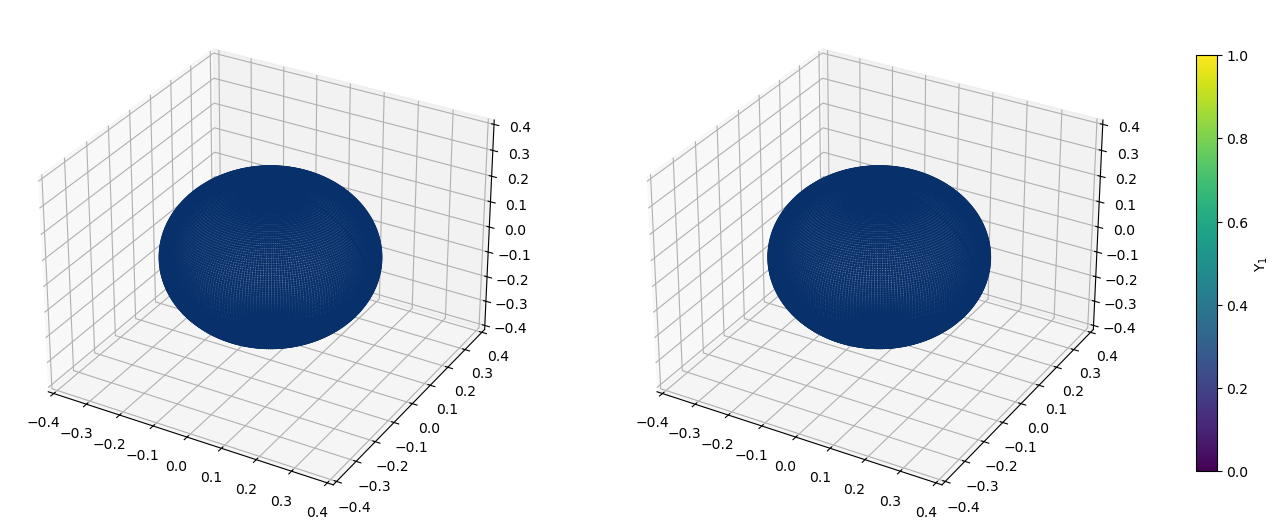

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(18, 9), subplot_kw={'projection': '3d'})

sc = axs[0].scatter(X_cart, Y_cart, Z_cart, s=1, color=(0.0314, 0.188, 0.42))
axs[0].set_xlim(-0.4, 0.4); axs[0].set_ylim(-0.4, 0.4); axs[0].set_zlim(-0.4, 0.4)

sc = axs[1].scatter(X_cart_rot, Y_cart_rot, Z_cart_rot, s=1, color=(0.0314, 0.188, 0.42))
axs[1].set_xlim(-0.4, 0.4); axs[1].set_ylim(-0.4, 0.4); axs[1].set_zlim(-0.4, 0.4)

plt.colorbar(sc, ax=axs, shrink=0.6, label='Y$_1$')
plt.show()

In [ ]:
l, m = 1, 0

# Define rotation
theta_rot, phi_rot = np.pi/6, 0
R = get_rotation_matrix(theta_rot, phi_rot)

# ── Original harmonic ──
Y_1_orig = sph_harm_y(l, m, THETA, PHI).real
X_cart, Y_cart, Z_cart = spherical_to_cartesian(np.abs(Y_1_orig), THETA, PHI)

# -- Rotated harmonic ──
Y_1_rot = rotate_sph_harm(l, m, R, THETA, PHI)
X_cart_rot, Y_cart_rot, Z_cart_rot = spherical_to_cartesian(np.abs(Y_1_rot), THETA, PHI)

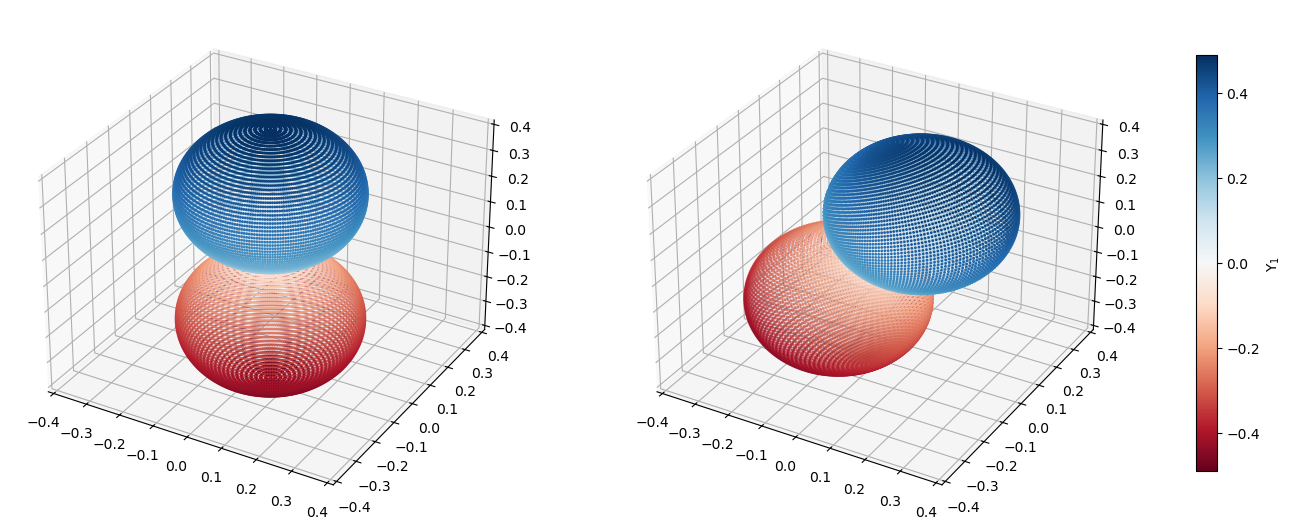

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(18, 9), subplot_kw={'projection': '3d'})

sc = axs[0].scatter(X_cart, Y_cart, Z_cart, s=1, c=Y_1_orig, cmap='RdBu')
axs[0].set_xlim(-0.4, 0.4); axs[0].set_ylim(-0.4, 0.4); axs[0].set_zlim(-0.4, 0.4)

sc = axs[1].scatter(X_cart_rot, Y_cart_rot, Z_cart_rot, s=1, c=Y_1_rot, cmap='RdBu')
axs[1].set_xlim(-0.4, 0.4); axs[1].set_ylim(-0.4, 0.4); axs[1].set_zlim(-0.4, 0.4)

plt.colorbar(sc, ax=axs, shrink=0.6, label='Y$_1$')
plt.show()

In [ ]:
l, m = 2, 0

# Define rotation
theta_rot, phi_rot = np.pi/8, 0
R = get_rotation_matrix(theta_rot, phi_rot)

# ── Original harmonic ──
Y_2_orig = sph_harm_y(l, m, THETA, PHI).real
X_cart, Y_cart, Z_cart = spherical_to_cartesian(np.abs(Y_2_orig), THETA, PHI)

# -- Rotated harmonic ──
Y_2_rot = rotate_sph_harm(l, m, R, THETA, PHI)
X_cart_rot, Y_cart_rot, Z_cart_rot = spherical_to_cartesian(np.abs(Y_2_rot), THETA, PHI)

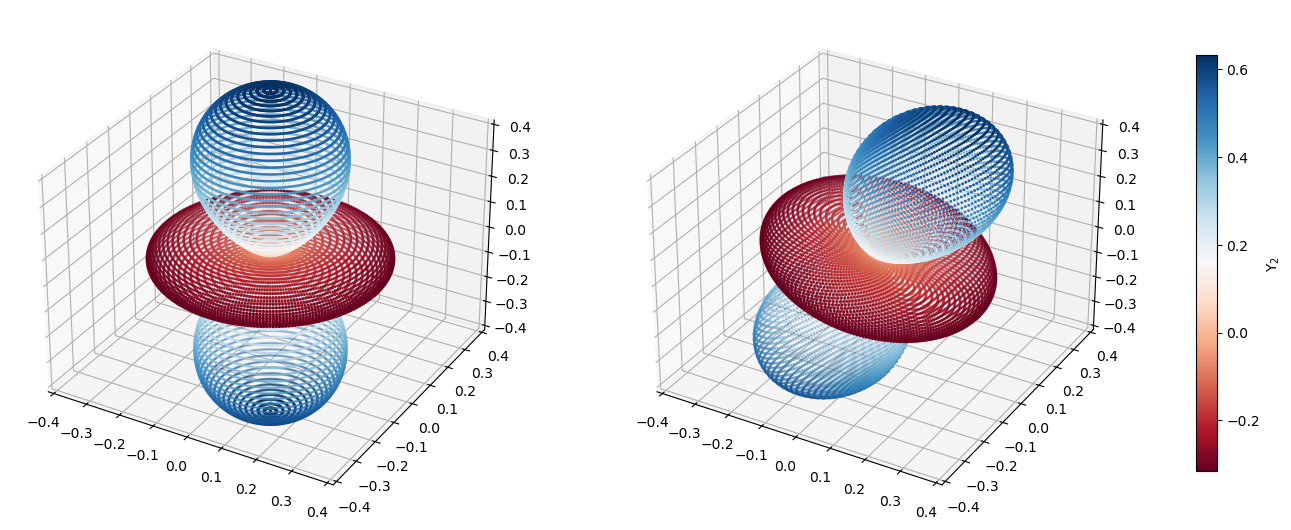

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(18, 9), subplot_kw={'projection': '3d'})

sc = axs[0].scatter(X_cart, Y_cart, Z_cart, s=1, c=Y_2_orig, cmap='RdBu')
axs[0].set_xlim(-0.4, 0.4); axs[0].set_ylim(-0.4, 0.4); axs[0].set_zlim(-0.4, 0.4)

sc = axs[1].scatter(X_cart_rot, Y_cart_rot, Z_cart_rot, s=1, c=Y_2_rot, cmap='RdBu')
axs[1].set_xlim(-0.4, 0.4); axs[1].set_ylim(-0.4, 0.4); axs[1].set_zlim(-0.4, 0.4)

plt.colorbar(sc, ax=axs, shrink=0.6, label=fr'Y$_{l}$')
plt.show()

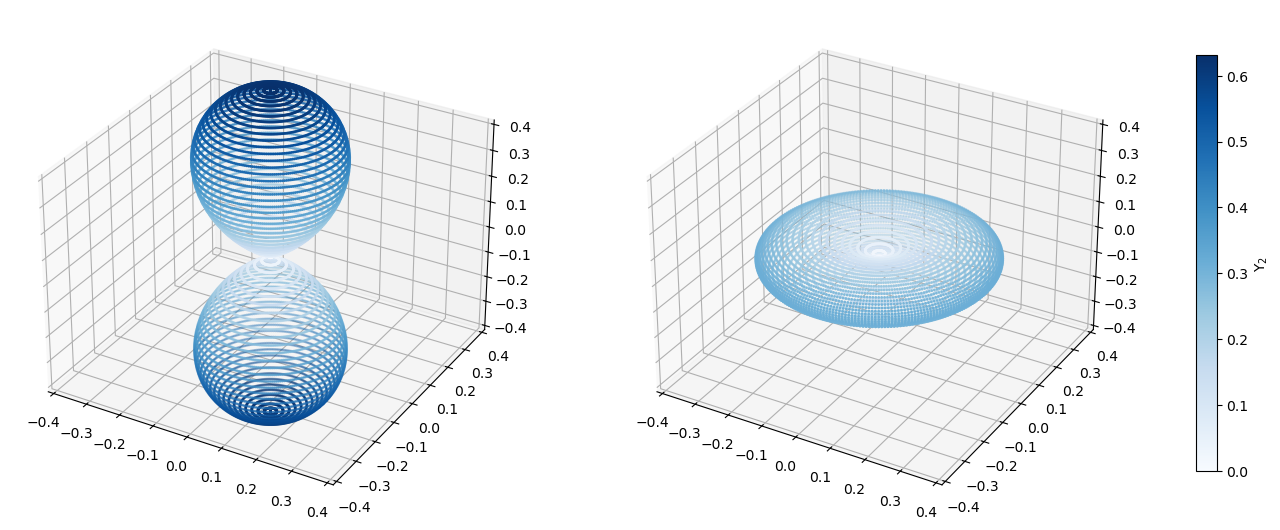

In [ ]:
relative_strength = 1
a = 2 * relative_strength / (relative_strength + 1)     # jet
b = 2 / (relative_strength + 1)                         # disk

jet = np.where(Y_2_rot > 0, Y_2_rot, 0)   * a
disk = np.where(Y_2_rot < 0, -Y_2_rot, 0) * b

X_jet, Y_jet, Z_jet = spherical_to_cartesian(jet, THETA, PHI)
X_disk, Y_disk, Z_disk = spherical_to_cartesian(disk, THETA, PHI)

fig, axs = plt.subplots(1, 2, figsize=(18, 9), subplot_kw={'projection': '3d'})

vmin = 0
vmax = max(jet.max(), disk.max())
norm = Normalize(vmin=vmin, vmax=vmax)

sc = axs[0].scatter(X_jet, Y_jet, Z_jet, s=1, c=jet, cmap='Blues', norm=norm)
axs[0].set_xlim(-0.4, 0.4); axs[0].set_ylim(-0.4, 0.4); axs[0].set_zlim(-0.4, 0.4)

sc = axs[1].scatter(X_disk, Y_disk, Z_disk, s=1, c=disk, cmap='Blues', norm=norm)
axs[1].set_xlim(-0.4, 0.4); axs[1].set_ylim(-0.4, 0.4); axs[1].set_zlim(-0.4, 0.4)

plt.colorbar(sc, ax=axs, shrink=0.6, label=fr'Y$_{l}$')
plt.show()